# case1 for dt=0.5

In [1]:
import os
import time
import psutil
import random
import warnings
import csv

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from scipy.optimize import fsolve
from scipy.optimize import minimize

# CONFIG

TF64 = True

NX_COARSE = 11
NX_FINE   = 201

L  = 2*np.pi
DT = 0.05

USE_SIREN    = True
SIREN_W0     = 15.0
HIDDEN_UNITS = 512
DEPTH        = 5

# Adam

EPOCHS      = 2500
LR          = 5e-5
SUP_WEIGHT  = 1.0
PHYS_WEIGHT = 0.1 / DT

BETA_L2   = 1e-6
GRAD_CLIP = 1.0
PATIENCE  = 800

# L-BFGS
USE_LBFGS     = True
LBFGS_MAXITER = 300
LBFGS_FTOL    = 1e-10

# OUTPUT PATHS
CASE_NAME = "CaseC_Hybrid"

OUT_DIR = f"{CASE_NAME}_results"
os.makedirs(OUT_DIR, exist_ok=True)

PLOTS_DIR = os.path.join(OUT_DIR, "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)

WEIGHTS_FILE = os.path.join(OUT_DIR, "caseC_hybrid.weights.h5")
META_FILE    = os.path.join(OUT_DIR, "caseC_hybrid_meta.npz")
DATA_FILE    = os.path.join(OUT_DIR, "training_pairs.npz")

METRICS_FILE = os.path.join(OUT_DIR, "timing_metrics.csv")

# REPRODUCIBILITY

if TF64:
    tf.keras.backend.set_floatx("float64")

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

warnings.filterwarnings("ignore")

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
tf.get_logger().setLevel("ERROR")

# memory utilities
process = psutil.Process(os.getpid())

def memory_mb():
    return process.memory_info().rss / 1024**2

print("\nCONFIG LOADED")
print("Initial memory usage: %.2f MB" % memory_mb())

# Spectral differentiation matrix

def generate_D_matrix(Nx, L):

    k = 2*np.pi*1j*np.fft.fftfreq(Nx, d=L/Nx)

    I = np.eye(Nx)

    D_fft = np.fft.ifft(
        k[:, None] * np.fft.fft(I, axis=0),
        axis=0
    )

    return D_fft.real

D_np = generate_D_matrix(NX_FINE, L)

D_tf = tf.constant(D_np, dtype=tf.float64)


# Residual
def residual_np(y, u):

    return y - u + 0.25 * DT * (D_np @ (y**2))

@tf.function
def residual_tf(y, u):

    y_sq = tf.square(y)

    dy_dx = tf.linalg.matmul(y_sq, tf.transpose(D_tf))

    return y - u + 0.25 * DT * dy_dx

# GRIDS

x_coarse = np.linspace(0, L, NX_COARSE, endpoint=False)
x_fine   = np.linspace(0, L, NX_FINE, endpoint=False)

# Fourier Interpolation
def fourier_interpolate(u_coarse, Nc, Nf):

    Uc = np.fft.fft(u_coarse)

    Uc_shift = np.fft.fftshift(Uc)

    pad_total = max(Nf-Nc, 0)

    pad_left  = pad_total // 2
    pad_right = pad_total - pad_left

    Uc_padded_shift = np.pad(
        Uc_shift,
        (pad_left, pad_right),
        mode="constant"
    )

    Uc_padded = np.fft.ifftshift(Uc_padded_shift)

    u_fine = np.fft.ifft(Uc_padded) * (Nf/Nc)

    return u_fine.real

# fsolve solver
def compute_y1_fsolve(un):

    un = np.asarray(un, dtype=np.float64)

    N = un.size

    def F(y):

        return y - un + 0.25*DT*(D_np @ (y**2))

    def J(y):

        return np.eye(N) + 0.5*DT*(D_np @ np.diag(y))

    y0 = un.copy()

    y_sol, info, ier, msg = fsolve(
        F,
        y0,
        fprime=J,
        xtol=1e-12,
        maxfev=30000,
        full_output=True
    )

    if ier != 1:
        print("[warn fsolve]", msg)

    return y_sol.astype(np.float64)

# Training functions
def make_rich_family():

    fns = []
    
    for k in range(1, 13):
        fns.append((f"sin({k}x)", lambda x, kk=k: np.sin(kk*x)))
        fns.append((f"cos({k}x)", lambda x, kk=k: np.cos(kk*x)))

    # phase shifted
    for k in range(1, 6):
        for phi in [0.3, 0.7, 1.2]:
            fns.append((f"sin({k}x+{phi})",
                        lambda x, kk=k, pp=phi: np.sin(kk*x + pp)))

    # fractional freq
    for k in [1.5, 2.5, 3.5, 4.5]:
        fns.append((f"sin({k}x)", lambda x, kk=k: np.sin(kk*x)))
    # polynomial-type nonlinearities
    fns += [
        ("sin^2(x)"     , lambda x: np.sin(x)**2),
        ("cos^2(x)"     , lambda x: np.cos(x)**2),
        ("sin^3(x)"     , lambda x: np.sin(x)**3),
        ("cos^3(x)"     , lambda x: np.cos(x)**3),
    ]
    
    # mixed modes
    fns += [
        ("sin+0.5sin2", lambda x: np.sin(x)+0.5*np.sin(2*x)),
        ("cos+0.5cos2", lambda x: np.cos(x)+0.5*np.cos(2*x)),
        ("sin2+cos3"  , lambda x: np.sin(2*x)+np.cos(3*x)),
        ("sin3+cos5"  , lambda x: np.sin(3*x)+0.7*np.cos(5*x)),
        ("sin5+sin7"  , lambda x: 0.6*np.sin(5*x)+0.4*np.sin(7*x)),
        ("cos4+cos8"  , lambda x: 0.5*np.cos(4*x)+0.5*np.cos(8*x)),
    ]
    # Gaussians times sines/cosines
    fns += [
        ("gauss*sin(5x)",  lambda x: np.exp(-(x-np.pi)**2)*np.sin(5*x)),
        ("gauss*sin(10x)", lambda x: np.exp(-(x-np.pi)**2)*np.sin(10*x)),
        ("gauss*cos(7x)",  lambda x: np.exp(-0.5*(x-np.pi)**2)*np.cos(7*x)),
    ]
    # exponentials & combinations
    fns += [
        ("exp(-x)sin(x)",  lambda x: np.exp(-0.2*x)*np.sin(x)),
        ("exp(-x)cos(3x)", lambda x: np.exp(-0.4*x)*np.cos(3*x)),
    ]
    # random linear combos of sines/cosines for more variety
    rng = np.random.default_rng(123)
    for idx in range(30):   # ~30 random ICs
        ks  = rng.integers(1, 13, size=3)
        a   = rng.uniform(-1.0, 1.0, size=3)
        b   = rng.uniform(-1.0, 1.0, size=3)
        def make_fn(ks=ks, a=a, b=b):
            return lambda x, ks=ks, a=a, b=b: (
                a[0]*np.sin(ks[0]*x) + a[1]*np.cos(ks[1]*x) + a[2]*np.sin(ks[2]*x)
                + b[0]*np.cos(ks[0]*x) + b[1]*np.sin(ks[1]*x) + b[2]*np.cos(ks[2]*x)
            )
        fns.append((f"rand_combo_{idx}", make_fn()))
    return fns

train_fns = make_rich_family()

print("Training family size:", len(train_fns))

# Generate/load data
if os.path.exists(DATA_FILE):

    dd = np.load(DATA_FILE, allow_pickle=True)

    un_train = dd["un"]

    y1_train = dd["y1"]

    print("Loaded cached data:", un_train.shape)

else:

    print("\nGenerating fsolve training data...")

    U_list = []
    Y_list = []

    for i, (name, fn) in enumerate(train_fns):

        u_c = fn(x_coarse)

        u_f = fourier_interpolate(
            u_c,
            NX_COARSE,
            NX_FINE
        )

        y1 = compute_y1_fsolve(u_f)

        U_list.append(u_f)
        Y_list.append(y1)

        print(f"{i+1}/{len(train_fns)} -> {name}")

    un_train = np.array(U_list)
    y1_train = np.array(Y_list)

    np.savez(DATA_FILE,
             un=un_train,
             y1=y1_train)

# FEATURES
def build_features(un_batch):

    mag = np.abs(
        np.fft.fft(un_batch, axis=-1)
    )[:, :NX_FINE//2+1]

    mag = 0.2 * mag

    return np.concatenate([un_batch, mag], axis=-1)

X_raw = build_features(un_train)

feat_mean = np.mean(X_raw, axis=0)

feat_std  = np.std(X_raw, axis=0) + 1e-12

X_norm = (X_raw - feat_mean) / feat_std

print("\nFeature shape:", X_norm.shape)

# Training

# SIREN LAYER
class SineDense(tf.keras.layers.Layer):

    def __init__(self,
                 units,
                 w0=30.0,
                 is_first=False,
                 **kwargs):

        super().__init__(dtype=tf.float64, **kwargs)

        self.units = int(units)
        self.w0 = float(w0)
        self.is_first = bool(is_first)

    def build(self, input_shape):

        in_dim = int(input_shape[-1])

        bound = (
            (1.0 / in_dim)
            if self.is_first
            else
            (np.sqrt(6.0/in_dim)/self.w0)
        )

        self.W = self.add_weight(
            shape=(in_dim, self.units),
            initializer=tf.keras.initializers.RandomUniform(
                -bound, bound
            ),
            trainable=True,
            dtype=tf.float64
        )

        self.b = self.add_weight(
            shape=(self.units,),
            initializer="zeros",
            trainable=True,
            dtype=tf.float64
        )

    def call(self, x):

        return tf.sin(
            self.w0 * (tf.matmul(x, self.W) + self.b)
        )

# MODEL
def build_model():

    input_dim = X_norm.shape[1]

    inputs = tf.keras.Input(
        shape=(input_dim,),
        dtype=tf.float64
    )

    h = inputs

    h = SineDense(
        HIDDEN_UNITS,
        w0=SIREN_W0,
        is_first=True
    )(h)

    for _ in range(DEPTH-1):

        h = SineDense(
            HIDDEN_UNITS,
            w0=SIREN_W0
        )(h)

    outputs = tf.keras.layers.Dense(
        NX_FINE,
        dtype=tf.float64
    )(h)

    return tf.keras.Model(inputs, outputs)

model = build_model()

_ = model(
    tf.zeros((1, X_norm.shape[1]), dtype=tf.float64)
)

print(model.count_params(), "parameters")

# into tensors
X_tf = tf.convert_to_tensor(X_norm, dtype=tf.float64)

U_tf = tf.convert_to_tensor(un_train, dtype=tf.float64)

Y_tf = tf.convert_to_tensor(y1_train, dtype=tf.float64)

optimizer = tf.keras.optimizers.Adam(LR)

# TRAINING
print("\nSTART TRAINING")

train_start = time.perf_counter()

peak_memory_before = memory_mb()

best_total = np.inf
wait = 0

for epoch in range(1, EPOCHS+1):

    with tf.GradientTape() as tape:

        y_pred = model(X_tf, training=True)

        sup_loss = tf.reduce_mean(
            tf.square(y_pred - Y_tf)
        )

        r = residual_tf(y_pred, U_tf)

        phys_loss = tf.reduce_mean(
            tf.square(r)
        )

        reg = BETA_L2 * tf.add_n([
            tf.nn.l2_loss(v)
            for v in model.trainable_variables
        ])

        total = (
            SUP_WEIGHT * sup_loss
            + PHYS_WEIGHT * phys_loss
            + reg
        )

    grads = tape.gradient(
        total,
        model.trainable_variables
    )

    grads = [
        tf.clip_by_norm(g, GRAD_CLIP)
        for g in grads
    ]

    optimizer.apply_gradients(
        zip(grads, model.trainable_variables)
    )

    if epoch % 100 == 0 or epoch == 1:

        print(
            f"Epoch {epoch:4d} | "
            f"Total={float(total):.3e} | "
            f"Sup={float(sup_loss):.3e} | "
            f"Phys={float(phys_loss):.3e}"
        )

    total_val = float(total.numpy())

    if total_val < best_total:

        best_total = total_val

        wait = 0

        model.save_weights(WEIGHTS_FILE)

    else:

        wait += 1

        if wait >= PATIENCE:

            print("Early stopping.")
            break

train_end = time.perf_counter()

train_time_sec = train_end - train_start

peak_memory_after = memory_mb()

peak_memory_used = (
    peak_memory_after - peak_memory_before
)

print("\nTRAINING COMPLETE")

print("Training time: %.2f sec" % train_time_sec)

print("Memory increase: %.2f MB" % peak_memory_used)

# L-BFGS POLISH
if USE_LBFGS:

    print("\n=== PHASE 2: L-BFGS polish (same hybrid loss) ===")

    # reloading best Adam weights

    model.load_weights(WEIGHTS_FILE)

    print("[L-BFGS] loaded best Adam weights")

    # parameter bookkeeping
    var_list = model.trainable_variables

    shapes = [v.shape for v in var_list]

    sizes = [int(np.prod(s)) for s in shapes]

    total_params = sum(sizes)

    print("[L-BFGS] total params =", total_params)

    # pack weights
    def pack_weights():

        return np.concatenate([
            v.numpy().ravel()
            for v in var_list
        ])

    # unpack weights
    def unpack_weights(theta):

        offset = 0

        for v, s, sz in zip(var_list, shapes, sizes):

            chunk = theta[offset:offset+sz]

            v.assign(chunk.reshape(s))

            offset += sz

    # same hybrid loss
    @tf.function
    def loss_and_grads_tf():

        with tf.GradientTape() as tape:

            y_pred = model(X_tf, training=True)

            # supervised loss
            sup_loss = tf.reduce_mean(
                tf.square(y_pred - Y_tf)
            )

            # physics residual
            r = residual_tf(y_pred, U_tf)

            phys_loss = tf.reduce_mean(
                tf.square(r)
            )

            # regularization
            reg = BETA_L2 * tf.add_n([
                tf.nn.l2_loss(v)
                for v in model.trainable_variables
            ])

            # hybrid total loss
            total = (
                SUP_WEIGHT * sup_loss
                + PHYS_WEIGHT * phys_loss
                + reg
            )

        grads = tape.gradient(total, var_list)

        return (
            total,
            grads,
            sup_loss,
            phys_loss
        )

    # scipy objective
    def lbfgs_objective(theta):

        unpack_weights(theta)

        total_tf, grads_tf, sup_tf, phys_tf = (
            loss_and_grads_tf()
        )

        loss_val = float(total_tf.numpy())

        grad_vec = np.concatenate([
            g.numpy().ravel()
            for g in grads_tf
        ])

        return loss_val, grad_vec

    # initial weights
    theta0 = pack_weights()

    # timing start
    lbfgs_start = time.perf_counter()

    # optimization
    result = minimize(

        lbfgs_objective,

        theta0,

        jac=True,

        method='L-BFGS-B',

        options={

            'maxiter': LBFGS_MAXITER,

            'ftol': LBFGS_FTOL,

            'maxcor': 50,

            'iprint': 1
        }
    )

    # timing end
    lbfgs_end = time.perf_counter()

    lbfgs_time = lbfgs_end - lbfgs_start

    print("\n[L-BFGS] optimization finished")

    print("[L-BFGS] time: %.2f sec" % lbfgs_time)

    print("[L-BFGS] success:",
          result.success)

    print("[L-BFGS] message:",
          result.message)

    # restore optimized weights
    unpack_weights(result.x)

    # final losses
    total_tf, _, sup_tf, phys_tf = (
        loss_and_grads_tf()
    )

    print(
        "\n[L-BFGS FINAL]"
    )

    print(
        "Total = %.3e"
        % float(total_tf.numpy())
    )

    print(
        "Sup   = %.3e"
        % float(sup_tf.numpy())
    )

    print(
        "Phys  = %.3e"
        % float(phys_tf.numpy())
    )

    # save polished weights
    model.save_weights(WEIGHTS_FILE)

    print(
        "\n[L-BFGS] saved polished weights:"
    )

    print(WEIGHTS_FILE)

# SAVE META

np.savez(

    META_FILE,

    feat_mean=feat_mean,
    feat_std=feat_std,

    NX_FINE=NX_FINE,
    NX_COARSE=NX_COARSE,

    DT=DT,
    L=L,

    HIDDEN_UNITS=HIDDEN_UNITS,
    DEPTH=DEPTH,
    SIREN_W0=SIREN_W0
)

print("\nSaved weights:", WEIGHTS_FILE)

print("Saved meta:", META_FILE)


CONFIG LOADED
Initial memory usage: 354.62 MB
Training family size: 88

Generating fsolve training data...
1/88 -> sin(1x)
2/88 -> cos(1x)
3/88 -> sin(2x)
4/88 -> cos(2x)
5/88 -> sin(3x)
6/88 -> cos(3x)
7/88 -> sin(4x)
8/88 -> cos(4x)
9/88 -> sin(5x)
10/88 -> cos(5x)
11/88 -> sin(6x)
12/88 -> cos(6x)
13/88 -> sin(7x)
14/88 -> cos(7x)
15/88 -> sin(8x)
16/88 -> cos(8x)
17/88 -> sin(9x)
18/88 -> cos(9x)
19/88 -> sin(10x)
20/88 -> cos(10x)
21/88 -> sin(11x)
22/88 -> cos(11x)
23/88 -> sin(12x)
24/88 -> cos(12x)
25/88 -> sin(1x+0.3)
26/88 -> sin(1x+0.7)
27/88 -> sin(1x+1.2)
28/88 -> sin(2x+0.3)
29/88 -> sin(2x+0.7)
30/88 -> sin(2x+1.2)
31/88 -> sin(3x+0.3)
32/88 -> sin(3x+0.7)
33/88 -> sin(3x+1.2)
34/88 -> sin(4x+0.3)
35/88 -> sin(4x+0.7)
36/88 -> sin(4x+1.2)
37/88 -> sin(5x+0.3)
38/88 -> sin(5x+0.7)
39/88 -> sin(5x+1.2)
40/88 -> sin(1.5x)
41/88 -> sin(2.5x)
42/88 -> sin(3.5x)
43/88 -> sin(4.5x)
44/88 -> sin^2(x)
45/88 -> cos^2(x)
46/88 -> sin^3(x)
47/88 -> cos^3(x)
48/88 -> sin+0.5sin2
49/

### Computation Metrics

In [3]:
# LOAD SAVED MODEL

model = build_model()

_ = model(
    tf.zeros((1, X_norm.shape[1]), dtype=tf.float64)
)

model.load_weights(WEIGHTS_FILE)

print("Loaded saved model.")

# FEATURE BUILDER

def build_feat_single(u_f):

    mag = np.abs(np.fft.fft(u_f))[:NX_FINE//2+1]

    mag = 0.2 * mag

    feats = np.concatenate([u_f, mag])

    return (
        (feats - feat_mean) / feat_std
    )[None, :]

# ROLLOUT
def rollout_nn(u0, steps=5):

    u = u0.copy()

    traj = [u.copy()]

    for _ in range(steps):

        feat = build_feat_single(u)

        y = model(
            tf.constant(feat, dtype=tf.float64),
            training=False
        ).numpy()[0]

        u = y.copy()

        traj.append(u.copy())

    return traj

# TEST FUNCTIONS
tests = [
    (
        "sin(x)",
        lambda x: np.sin(x)
    ),
    (
        "0.5+0.25sin(x)",
        lambda x: 0.5 + 0.25*np.sin(x)
    ),
    # Irrational-frequency sin/cos
    (
        "sin(sqrt(2)x)",
        lambda x: np.sin(np.sqrt(2)*x)
    ),
    (
        "cos(sqrt(3)x)",
        lambda x: np.cos(np.sqrt(3)*x)
    ),
    # Gaussian+irrational frequency
    (
        "exp(-(x-pi)^2)*sin(sqrt(2)x)",
        lambda x: np.exp(-(x - np.pi)**2)
                  * np.sin(np.sqrt(2)*x)
    ),
    # Normalized polynomial family
    (
        "((x-pi)^2)/(pi^2)",
        lambda x: ((x - np.pi)**2)
    ),
    (
        "(pi^2-(x-pi)^2)/(pi^2)",
        lambda x: (np.pi**2 - (x - np.pi)**2) 
    )
]
# METRICS
rows = []

for name, fn in tests:

    print("\n====================")
    print(name)

    uf = fourier_interpolate(
        fn(x_coarse),
        NX_COARSE,
        NX_FINE
    )

    # SINGLE STEP NN

    feat = build_feat_single(uf)

    t0 = time.perf_counter()

    y_pred = model(
        tf.constant(feat, dtype=tf.float64),
        training=False
    ).numpy()[0]

    t1 = time.perf_counter()

    nn_ms = 1000 * (t1 - t0)

    # FSOLVE BASELINE
    fs0 = time.perf_counter()

    y_fs = compute_y1_fsolve(uf)

    fs1 = time.perf_counter()

    fsolve_ms = 1000 * (fs1 - fs0)

    # ROLLOUT
    r0 = time.perf_counter()

    traj_nn = rollout_nn(uf, steps=5)

    r1 = time.perf_counter()

    rollout_sec = r1 - r0
    
    # Residual
    r = residual_np(y_pred, uf)

    Linf = np.max(np.abs(r))

    Mean = np.mean(np.abs(r))

    # Memory
    mem_now = memory_mb()

    print(f"NN inference: {nn_ms:.3f} ms")

    print(f"fsolve solve : {fsolve_ms:.3f} ms")

    print(f"5-step rollout: {rollout_sec:.3f} sec")

    print(f"Memory usage: {mem_now:.2f} MB")

    print(f"Linf residual: {Linf:.3e}")

    rows.append([

        name,

        nn_ms,

        fsolve_ms,

        rollout_sec,

        mem_now,

        Linf,

        Mean
    ])

# SAVE CSV
with open(METRICS_FILE, "w", newline="") as f:

    writer = csv.writer(f)

    writer.writerow([

        "Function",

        "NN_Inference_ms",

        "fsolve_ms",

        "Rollout_sec",

        "Memory_MB",

        "Linf",

        "MeanResidual"
    ])

    writer.writerows(rows)

print("\nSaved metrics CSV:")
print(METRICS_FILE)

Loaded saved model.

sin(x)
NN inference: 8.230 ms
fsolve solve : 31.697 ms
5-step rollout: 0.055 sec
Memory usage: 1592.45 MB
Linf residual: 1.974e-03

0.5+0.25sin(x)
NN inference: 10.289 ms
fsolve solve : 34.483 ms
5-step rollout: 0.040 sec
Memory usage: 1592.45 MB
Linf residual: 3.545e-01

sin(sqrt(2)x)
NN inference: 9.696 ms
fsolve solve : 22.717 ms
5-step rollout: 0.034 sec
Memory usage: 1592.45 MB
Linf residual: 2.079e-01

cos(sqrt(3)x)
NN inference: 8.065 ms
fsolve solve : 22.846 ms
5-step rollout: 0.040 sec
Memory usage: 1592.45 MB
Linf residual: 3.804e-01

exp(-(x-pi)^2)*sin(sqrt(2)x)
NN inference: 11.737 ms
fsolve solve : 36.398 ms
5-step rollout: 0.062 sec
Memory usage: 1592.45 MB
Linf residual: 5.729e-01

((x-pi)^2)/(pi^2)
NN inference: 9.449 ms
fsolve solve : 40.114 ms
5-step rollout: 0.039 sec
Memory usage: 1592.45 MB
Linf residual: 9.534e+00

(pi^2-(x-pi)^2)/(pi^2)
NN inference: 9.081 ms
fsolve solve : 24.837 ms
5-step rollout: 0.049 sec
Memory usage: 1592.45 MB
Linf res

### Testing


Loaded saved model.

TEST & DIAGNOSTICS

--- sin(x) ---
[test] sin(x)       | L∞=2.451e-03 | Mean=5.711e-04
NN inference : 7.996 ms
fsolve solve : 24.150 ms
5-step rollout: 0.032 sec
Memory usage : 422.83 MB


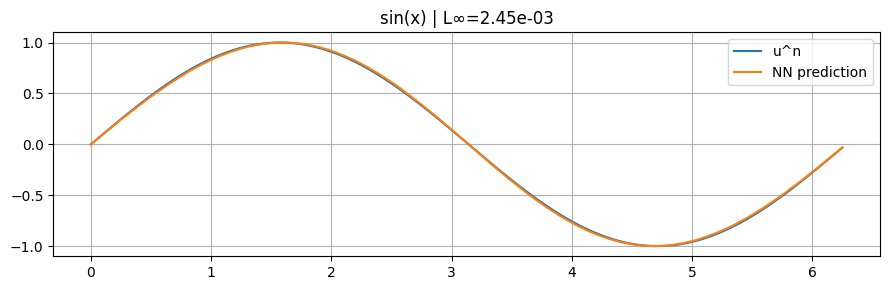

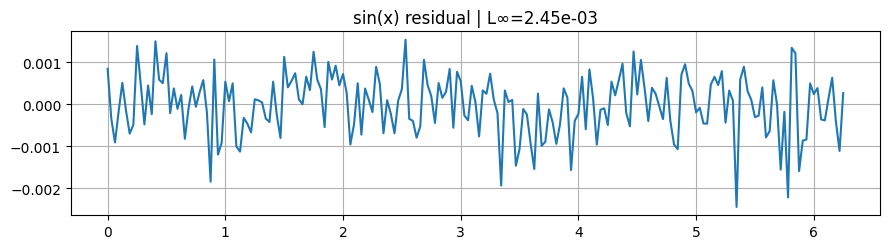

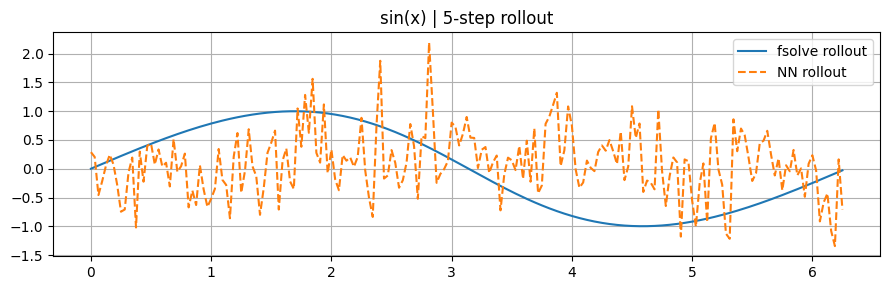


--- 0.5+0.25sin(x) ---
[test] 0.5+0.25sin(x) | L∞=3.823e-01 | Mean=1.066e-01
NN inference : 7.890 ms
fsolve solve : 23.252 ms
5-step rollout: 0.033 sec
Memory usage : 426.08 MB


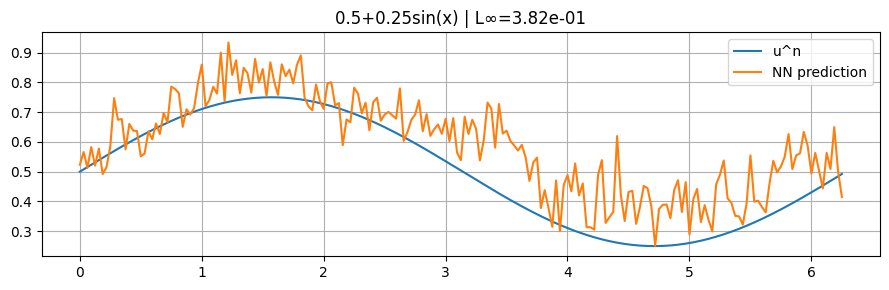

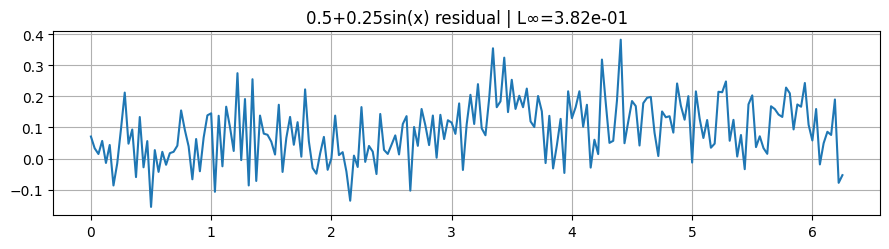

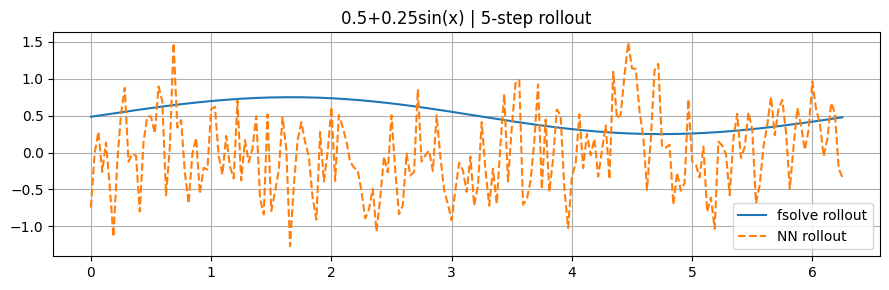


--- sin(sqrt(2)x) ---
[test] sin(sqrt(2)x) | L∞=2.405e-01 | Mean=6.216e-02
NN inference : 8.515 ms
fsolve solve : 24.573 ms
5-step rollout: 0.035 sec
Memory usage : 430.48 MB


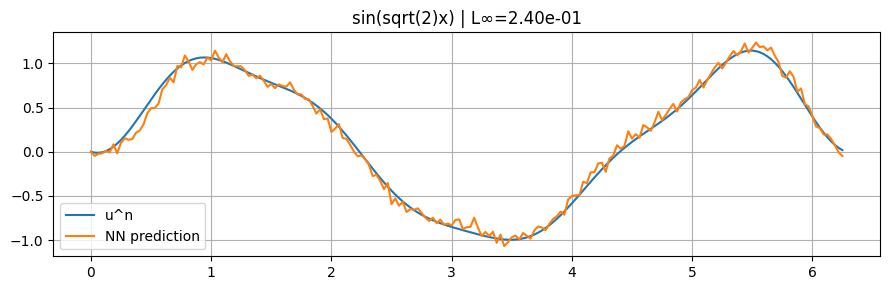

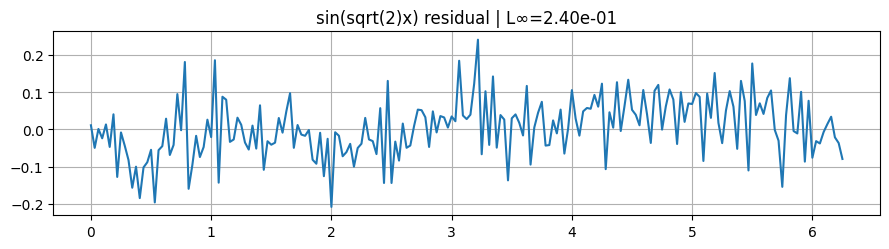

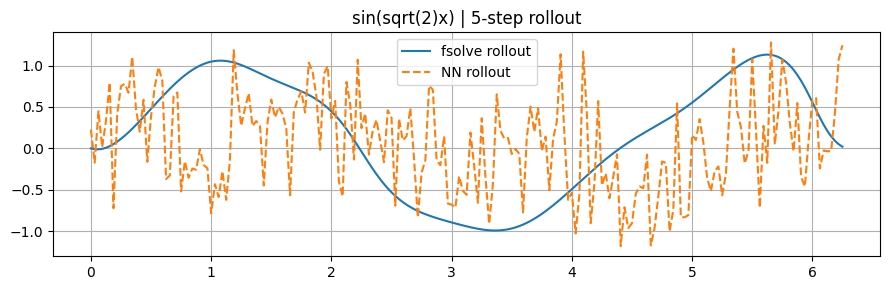


--- cos(sqrt(3)x) ---
[test] cos(sqrt(3)x) | L∞=5.427e-01 | Mean=1.258e-01
NN inference : 7.470 ms
fsolve solve : 32.390 ms
5-step rollout: 0.046 sec
Memory usage : 420.30 MB


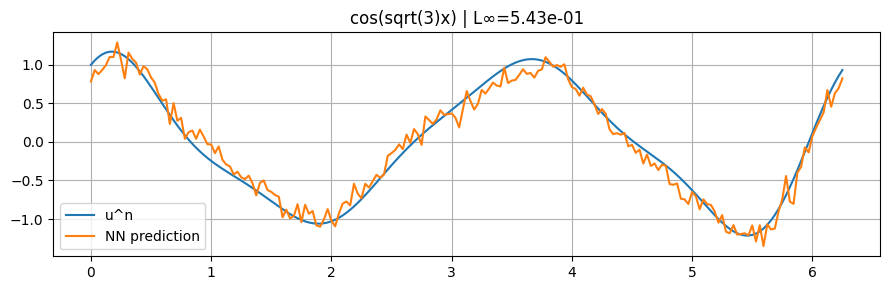

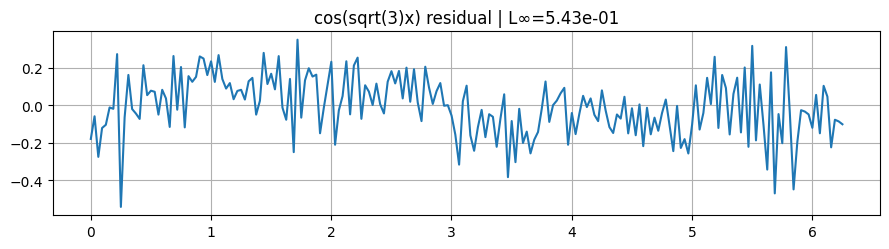

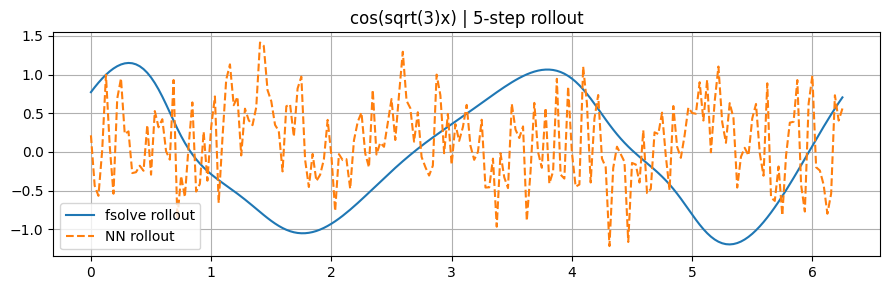


--- exp(-(x-pi)^2)*sin(sqrt(2)x) ---
[test] exp(-(x-pi)^2)*sin(sqrt(2)x) | L∞=6.218e-01 | Mean=1.840e-01
NN inference : 10.494 ms
fsolve solve : 24.950 ms
5-step rollout: 0.034 sec
Memory usage : 420.63 MB


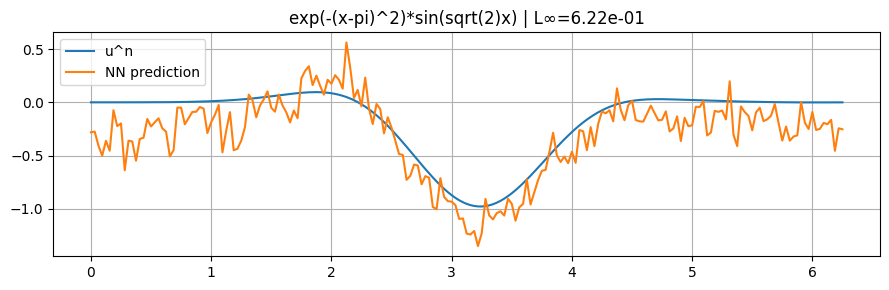

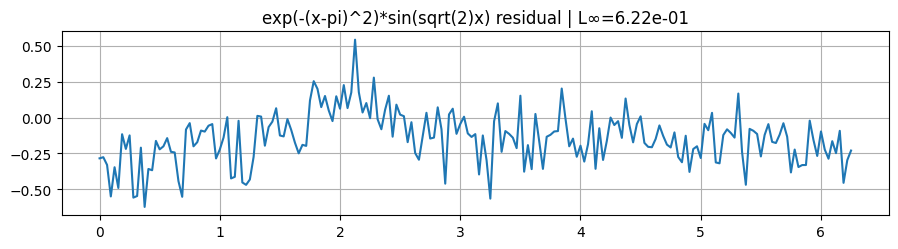

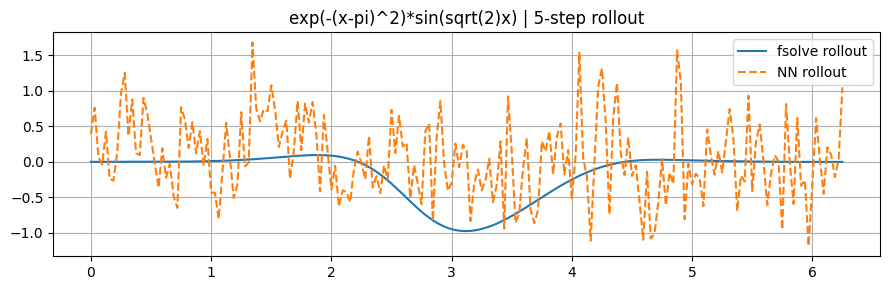


--- ((x-pi)^2)/(pi^2) ---
[test] ((x-pi)^2)/(pi^2) | L∞=4.882e-01 | Mean=9.478e-02
NN inference : 7.195 ms
fsolve solve : 33.283 ms
5-step rollout: 0.055 sec
Memory usage : 424.41 MB


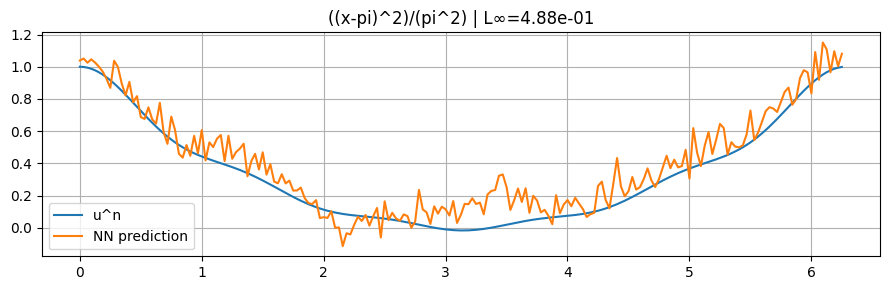

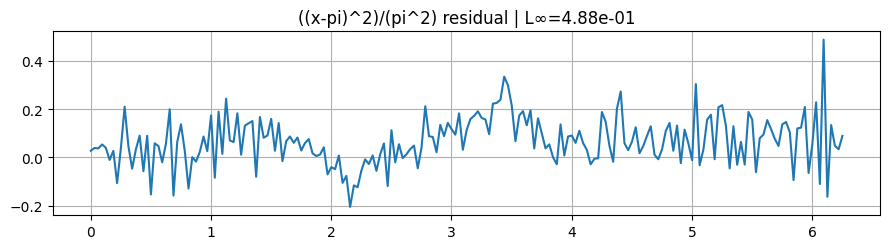

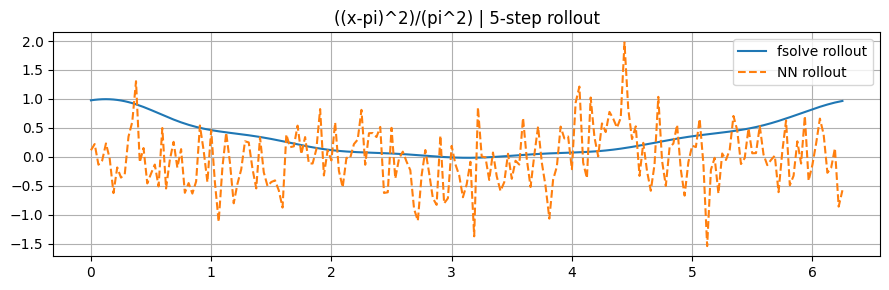


--- (pi^2-(x-pi)^2)/(pi^2) ---
[test] (pi^2-(x-pi)^2)/(pi^2) | L∞=5.571e-01 | Mean=1.557e-01
NN inference : 8.659 ms
fsolve solve : 22.052 ms
5-step rollout: 0.038 sec
Memory usage : 426.47 MB


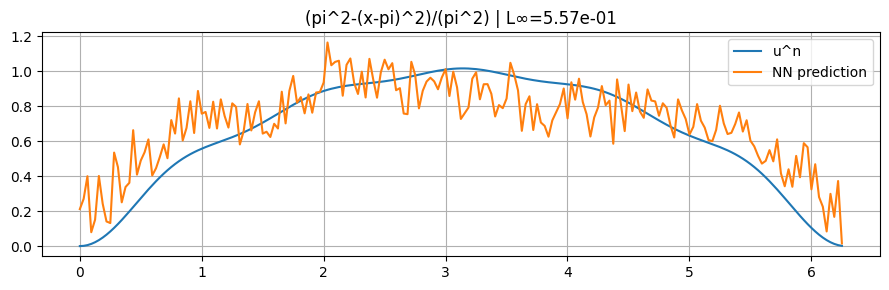

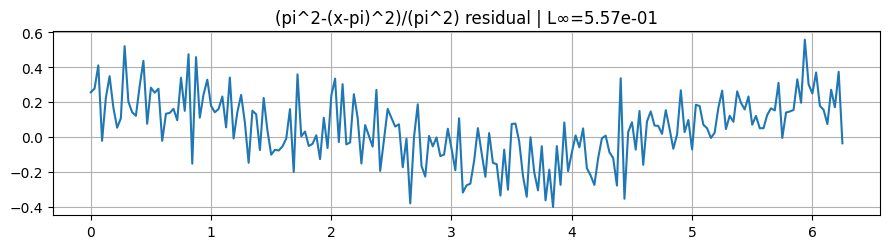

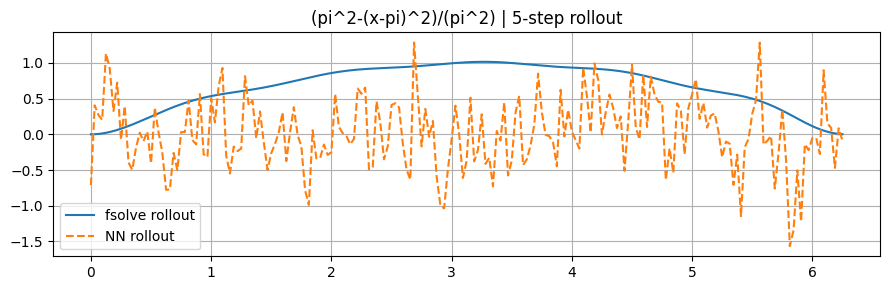


Saved summary CSV:
CaseC_Hybrid_results\testing_summary.csv

Plots saved in:
CaseC_Hybrid_results\plots


In [2]:
# TEST & DIAGNOSTICS
import os
import csv
import time
import psutil

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from scipy.optimize import fsolve

# PATHS
OUT_DIR = "CaseC_Hybrid_results"

PLOTS_DIR = os.path.join(OUT_DIR, "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)

WEIGHTS_FILE = os.path.join(
    OUT_DIR,
    "caseC_hybrid.weights.h5"
)

META_FILE = os.path.join(
    OUT_DIR,
    "caseC_hybrid_meta.npz"
)

CSV_FILE = os.path.join(
    OUT_DIR,
    "testing_summary.csv"
)

# MEMORY
process = psutil.Process(os.getpid())

def memory_mb():

    return process.memory_info().rss / 1024**2


# LOAD META
meta = np.load(META_FILE, allow_pickle=True)

NX_FINE   = int(meta["NX_FINE"])
NX_COARSE = int(meta["NX_COARSE"])

DT = float(meta["DT"])
L  = float(meta["L"])

HIDDEN_UNITS = int(meta["HIDDEN_UNITS"])
DEPTH        = int(meta["DEPTH"])
SIREN_W0     = float(meta["SIREN_W0"])

feat_mean = meta["feat_mean"]
feat_std  = meta["feat_std"]

# GRIDS
x_coarse = np.linspace(
    0,
    L,
    NX_COARSE,
    endpoint=False
)

x_fine = np.linspace(
    0,
    L,
    NX_FINE,
    endpoint=False
)

# Differentiaiton matrix
def generate_D_matrix(Nx, L):

    k = 2*np.pi*1j*np.fft.fftfreq(
        Nx,
        d=L/Nx
    )

    I = np.eye(Nx)

    D_fft = np.fft.ifft(
        k[:, None] * np.fft.fft(I, axis=0),
        axis=0
    )

    return D_fft.real

D_np = generate_D_matrix(NX_FINE, L)

# Residual
def residual_np(y, u):

    return y - u + 0.25*DT*(D_np @ (y**2))

# Fourier Interpolation
def fourier_interpolate(u_coarse, Nc, Nf):

    Uc = np.fft.fft(u_coarse)

    Uc_shift = np.fft.fftshift(Uc)

    pad_total = max(Nf-Nc, 0)

    pad_left  = pad_total // 2
    pad_right = pad_total - pad_left

    Uc_padded_shift = np.pad(
        Uc_shift,
        (pad_left, pad_right),
        mode="constant"
    )

    Uc_padded = np.fft.ifftshift(
        Uc_padded_shift
    )

    u_fine = np.fft.ifft(Uc_padded) * (Nf/Nc)

    return u_fine.real

# Fsolve
def compute_y1_fsolve(un):

    un = np.asarray(un, dtype=np.float64)

    N = un.size

    def F(y):

        return y - un + 0.25*DT*(D_np @ (y**2))

    def J(y):

        return np.eye(N) + 0.5*DT*(D_np @ np.diag(y))

    y0 = un.copy()

    y_sol = fsolve(
        F,
        y0,
        fprime=J,
        xtol=1e-12
    )

    return y_sol.astype(np.float64)

# Siren layer
class SineDense(tf.keras.layers.Layer):

    def __init__(
        self,
        units,
        w0=30.0,
        is_first=False,
        **kwargs
    ):

        super().__init__(
            dtype=tf.float64,
            **kwargs
        )

        self.units = int(units)

        self.w0 = float(w0)

        self.is_first = bool(is_first)

    def build(self, input_shape):

        in_dim = int(input_shape[-1])

        bound = (
            (1.0/in_dim)
            if self.is_first
            else
            (np.sqrt(6.0/in_dim)/self.w0)
        )

        self.W = self.add_weight(
            shape=(in_dim, self.units),
            initializer=tf.keras.initializers.RandomUniform(
                -bound,
                bound
            ),
            trainable=True,
            dtype=tf.float64
        )

        self.b = self.add_weight(
            shape=(self.units,),
            initializer="zeros",
            trainable=True,
            dtype=tf.float64
        )

    def call(self, x):

        return tf.sin(
            self.w0 * (
                tf.matmul(x, self.W) + self.b
            )
        )

# Build model
def build_model():

    input_dim = len(feat_mean)

    inputs = tf.keras.Input(
        shape=(input_dim,),
        dtype=tf.float64
    )

    h = inputs

    h = SineDense(
        HIDDEN_UNITS,
        w0=SIREN_W0,
        is_first=True
    )(h)

    for _ in range(DEPTH-1):

        h = SineDense(
            HIDDEN_UNITS,
            w0=SIREN_W0
        )(h)

    outputs = tf.keras.layers.Dense(
        NX_FINE,
        dtype=tf.float64
    )(h)

    return tf.keras.Model(inputs, outputs)

model = build_model()

_ = model(
    tf.zeros((1, len(feat_mean)), dtype=tf.float64)
)

model.load_weights(WEIGHTS_FILE)

print("\nLoaded saved model.")

# SAFE FILENAME
def safe_filename(name):

    return (
        name.replace("(", "")
            .replace(")", "")
            .replace("*", "")
            .replace("^", "")
            .replace("+", "")
            .replace("-", "")
            .replace("/", "_")
            .replace("\\", "_")
            .replace("=", "_")
            .replace(" ", "_")
    )

# Features
def build_feat_single(u_f):

    mag = np.abs(
        np.fft.fft(u_f)
    )[:NX_FINE//2+1]

    mag = 0.2 * mag

    feats = np.concatenate([u_f, mag])

    return (
        (feats - feat_mean) / feat_std
    )[None, :]

# Rollout
def rollout_nn(u0, steps=5):

    u = u0.copy()

    traj = [u.copy()]

    for _ in range(steps):

        feat = build_feat_single(u)

        y = model(
            tf.constant(feat, dtype=tf.float64),
            training=False
        ).numpy()[0]

        u = y.copy()

        traj.append(u.copy())

    return traj

# NORMALIZED OOD TEST FUNCTIONS
tests = [
    (
        "sin(x)",
        lambda x: np.sin(x)
    ),
    
    (
        "0.5+0.25sin(x)",
        lambda x: 0.5 + 0.25*np.sin(x)
    ), 
    # Irrational-frequency sin/cos
    (
        "sin(sqrt(2)x)",
        lambda x: np.sin(np.sqrt(2)*x)
    ),

    (
        "cos(sqrt(3)x)",
        lambda x: np.cos(np.sqrt(3)*x)
    ),   
    # Gaussian + irrational frequency
    (
        "exp(-(x-pi)^2)*sin(sqrt(2)x)",
        lambda x: np.exp(-(x - np.pi)**2)
                  * np.sin(np.sqrt(2)*x)
    ),      
    # Normalised polynomial family
    (
        "((x-pi)^2)/(pi^2)",
        lambda x: ((x - np.pi)**2) / (np.pi**2)
    ),

    (
        "(pi^2-(x-pi)^2)/(pi^2)",
        lambda x: (np.pi**2 - (x - np.pi)**2) / (np.pi**2)
    )
    
]

summary = []


# TESTING

print("\nTEST & DIAGNOSTICS")

for name, fn in tests:

    print("\n---", name, "---")

    safe_name = safe_filename(name)
    
    # initial condition
    uf = fourier_interpolate(
        fn(x_coarse),
        NX_COARSE,
        NX_FINE
    )

    # NN prediction timing
    feat = build_feat_single(uf)

    t0 = time.perf_counter()

    y_pred = model(
        tf.constant(feat, dtype=tf.float64),
        training=False
    ).numpy()[0]

    t1 = time.perf_counter()

    nn_ms = 1000 * (t1 - t0)

    # fsolve timing
    fs0 = time.perf_counter()

    y_fs = compute_y1_fsolve(uf)

    fs1 = time.perf_counter()

    fsolve_ms = 1000 * (fs1 - fs0)

    # residual
    r = residual_np(y_pred, uf)

    Linf = float(np.max(np.abs(r)))

    Mean = float(np.mean(np.abs(r)))

    # rollout timing
    steps = 5

    r0 = time.perf_counter()

    traj_nn = rollout_nn(uf, steps)

    r1 = time.perf_counter()

    rollout_sec = r1 - r0

    # fsolve rollout

    traj_fs = [uf.copy()]

    tmp = uf.copy()

    for _ in range(steps):

        tmp = compute_y1_fsolve(tmp)

        traj_fs.append(tmp.copy())

    mem_now = memory_mb()

    print(
        f"[test] {name:12s} | "
        f"L∞={Linf:.3e} | "
        f"Mean={Mean:.3e}"
    )

    print(f"NN inference : {nn_ms:.3f} ms")

    print(f"fsolve solve : {fsolve_ms:.3f} ms")

    print(f"5-step rollout: {rollout_sec:.3f} sec")

    print(f"Memory usage : {mem_now:.2f} MB")

    xs = x_fine

    # Solution plot
    plt.figure(figsize=(9,3))

    plt.plot(xs, uf, label="u^n")

    plt.plot(xs, y_pred, label="NN prediction")

    plt.legend()

    plt.title(f"{name} | L∞={Linf:.2e}")

    plt.grid(True)

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            PLOTS_DIR,
            f"{safe_name}_nn.png"
        ),
        dpi=150
    )

    plt.show()

    # Residual plot
    plt.figure(figsize=(9,2.6))

    plt.plot(xs, r)

    plt.title(f"{name} residual | L∞={Linf:.2e}")

    plt.grid(True)

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            PLOTS_DIR,
            f"{safe_name}_res.png"
        ),
        dpi=150
    )

    plt.show()

    # Rollout plot
    plt.figure(figsize=(9,3))

    plt.plot(
        xs,
        traj_fs[-1],
        label="fsolve rollout"
    )

    plt.plot(
        xs,
        traj_nn[-1],
        "--",
        label="NN rollout"
    )

    plt.legend()

    plt.title(f"{name} | {steps}-step rollout")

    plt.grid(True)

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            PLOTS_DIR,
            f"{safe_name}_rollout.png"
        ),
        dpi=150
    )

    plt.show()

    summary.append([

        name,

        Linf,

        Mean,

        nn_ms,

        fsolve_ms,

        rollout_sec,

        mem_now
    ])

# SAVE CSV
with open(CSV_FILE, "w", newline="") as f:

    writer = csv.writer(f)

    writer.writerow([

        "Function",

        "Linf",

        "MeanResidual",

        "NN_Inference_ms",

        "fsolve_ms",

        "Rollout_sec",

        "Memory_MB"
    ])

    writer.writerows(summary)

print("\nSaved summary CSV:")

print(CSV_FILE)

print("\nPlots saved in:")

print(PLOTS_DIR)

# Case 2 for dt=0.005

In [1]:
import os
import time
import psutil
import random
import warnings
import csv

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from scipy.optimize import fsolve
from scipy.optimize import minimize

# CONFIG

TF64 = True

NX_COARSE = 11
NX_FINE   = 201

L  = 2*np.pi
DT = 0.005

USE_SIREN    = True
SIREN_W0     = 15.0
HIDDEN_UNITS = 512
DEPTH        = 5

# Adam

EPOCHS      = 2500
LR          = 5e-5
SUP_WEIGHT  = 1.0
PHYS_WEIGHT = 0.1 / DT

BETA_L2   = 1e-6
GRAD_CLIP = 1.0
PATIENCE  = 800

# L-BFGS
USE_LBFGS     = True
LBFGS_MAXITER = 300
LBFGS_FTOL    = 1e-10

# OUTPUT PATHS
CASE_NAME = "CaseC_Hybrid_0.005"

OUT_DIR = f"{CASE_NAME}_results"
os.makedirs(OUT_DIR, exist_ok=True)

PLOTS_DIR = os.path.join(OUT_DIR, "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)

WEIGHTS_FILE = os.path.join(OUT_DIR, "caseC_hybrid_0.005.weights.h5")
META_FILE    = os.path.join(OUT_DIR, "caseC_hybrid_meta_0.005.npz")
DATA_FILE    = os.path.join(OUT_DIR, "training_pairr_0.005.npz")

METRICS_FILE = os.path.join(OUT_DIR, "timing_metrics_0.005.csv")

# REPRODUCIBILITY

if TF64:
    tf.keras.backend.set_floatx("float64")

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

warnings.filterwarnings("ignore")

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
tf.get_logger().setLevel("ERROR")

# memory utilities
process = psutil.Process(os.getpid())

def memory_mb():
    return process.memory_info().rss / 1024**2

print("\nCONFIG LOADED")
print("Initial memory usage: %.2f MB" % memory_mb())

# Spectral differentiation matrix

def generate_D_matrix(Nx, L):

    k = 2*np.pi*1j*np.fft.fftfreq(Nx, d=L/Nx)

    I = np.eye(Nx)

    D_fft = np.fft.ifft(
        k[:, None] * np.fft.fft(I, axis=0),
        axis=0
    )

    return D_fft.real

D_np = generate_D_matrix(NX_FINE, L)

D_tf = tf.constant(D_np, dtype=tf.float64)


# Residual
def residual_np(y, u):

    return y - u + 0.25 * DT * (D_np @ (y**2))

@tf.function
def residual_tf(y, u):

    y_sq = tf.square(y)

    dy_dx = tf.linalg.matmul(y_sq, tf.transpose(D_tf))

    return y - u + 0.25 * DT * dy_dx

# GRIDS

x_coarse = np.linspace(0, L, NX_COARSE, endpoint=False)
x_fine   = np.linspace(0, L, NX_FINE, endpoint=False)

# Fourier Interpolation
def fourier_interpolate(u_coarse, Nc, Nf):

    Uc = np.fft.fft(u_coarse)

    Uc_shift = np.fft.fftshift(Uc)

    pad_total = max(Nf-Nc, 0)

    pad_left  = pad_total // 2
    pad_right = pad_total - pad_left

    Uc_padded_shift = np.pad(
        Uc_shift,
        (pad_left, pad_right),
        mode="constant"
    )

    Uc_padded = np.fft.ifftshift(Uc_padded_shift)

    u_fine = np.fft.ifft(Uc_padded) * (Nf/Nc)

    return u_fine.real

# fsolve solver
def compute_y1_fsolve(un):

    un = np.asarray(un, dtype=np.float64)

    N = un.size

    def F(y):

        return y - un + 0.25*DT*(D_np @ (y**2))

    def J(y):

        return np.eye(N) + 0.5*DT*(D_np @ np.diag(y))

    y0 = un.copy()

    y_sol, info, ier, msg = fsolve(
        F,
        y0,
        fprime=J,
        xtol=1e-12,
        maxfev=30000,
        full_output=True
    )

    if ier != 1:
        print("[warn fsolve]", msg)

    return y_sol.astype(np.float64)

# Training functions
def make_rich_family():

    fns = []
    
    for k in range(1, 13):
        fns.append((f"sin({k}x)", lambda x, kk=k: np.sin(kk*x)))
        fns.append((f"cos({k}x)", lambda x, kk=k: np.cos(kk*x)))

    # phase shifted
    for k in range(1, 6):
        for phi in [0.3, 0.7, 1.2]:
            fns.append((f"sin({k}x+{phi})",
                        lambda x, kk=k, pp=phi: np.sin(kk*x + pp)))

    # fractional freq
    for k in [1.5, 2.5, 3.5, 4.5]:
        fns.append((f"sin({k}x)", lambda x, kk=k: np.sin(kk*x)))
    # polynomial-type nonlinearities
    fns += [
        ("sin^2(x)"     , lambda x: np.sin(x)**2),
        ("cos^2(x)"     , lambda x: np.cos(x)**2),
        ("sin^3(x)"     , lambda x: np.sin(x)**3),
        ("cos^3(x)"     , lambda x: np.cos(x)**3),
    ]
    
    # mixed modes
    fns += [
        ("sin+0.5sin2", lambda x: np.sin(x)+0.5*np.sin(2*x)),
        ("cos+0.5cos2", lambda x: np.cos(x)+0.5*np.cos(2*x)),
        ("sin2+cos3"  , lambda x: np.sin(2*x)+np.cos(3*x)),
        ("sin3+cos5"  , lambda x: np.sin(3*x)+0.7*np.cos(5*x)),
        ("sin5+sin7"  , lambda x: 0.6*np.sin(5*x)+0.4*np.sin(7*x)),
        ("cos4+cos8"  , lambda x: 0.5*np.cos(4*x)+0.5*np.cos(8*x)),
    ]
    # Gaussians times sines/cosines
    fns += [
        ("gauss*sin(5x)",  lambda x: np.exp(-(x-np.pi)**2)*np.sin(5*x)),
        ("gauss*sin(10x)", lambda x: np.exp(-(x-np.pi)**2)*np.sin(10*x)),
        ("gauss*cos(7x)",  lambda x: np.exp(-0.5*(x-np.pi)**2)*np.cos(7*x)),
    ]
    # exponentials & combinations
    fns += [
        ("exp(-x)sin(x)",  lambda x: np.exp(-0.2*x)*np.sin(x)),
        ("exp(-x)cos(3x)", lambda x: np.exp(-0.4*x)*np.cos(3*x)),
    ]
    # random linear combos of sines/cosines for more variety
    rng = np.random.default_rng(123)
    for idx in range(30):   # ~30 random ICs
        ks  = rng.integers(1, 13, size=3)
        a   = rng.uniform(-1.0, 1.0, size=3)
        b   = rng.uniform(-1.0, 1.0, size=3)
        def make_fn(ks=ks, a=a, b=b):
            return lambda x, ks=ks, a=a, b=b: (
                a[0]*np.sin(ks[0]*x) + a[1]*np.cos(ks[1]*x) + a[2]*np.sin(ks[2]*x)
                + b[0]*np.cos(ks[0]*x) + b[1]*np.sin(ks[1]*x) + b[2]*np.cos(ks[2]*x)
            )
        fns.append((f"rand_combo_{idx}", make_fn()))
    return fns

train_fns = make_rich_family()

print("Training family size:", len(train_fns))

# Generate/load data
if os.path.exists(DATA_FILE):

    dd = np.load(DATA_FILE, allow_pickle=True)

    un_train = dd["un"]

    y1_train = dd["y1"]

    print("Loaded cached data:", un_train.shape)

else:

    print("\nGenerating fsolve training data...")

    U_list = []
    Y_list = []

    for i, (name, fn) in enumerate(train_fns):

        u_c = fn(x_coarse)

        u_f = fourier_interpolate(
            u_c,
            NX_COARSE,
            NX_FINE
        )

        y1 = compute_y1_fsolve(u_f)

        U_list.append(u_f)
        Y_list.append(y1)

        print(f"{i+1}/{len(train_fns)} -> {name}")

    un_train = np.array(U_list)
    y1_train = np.array(Y_list)

    np.savez(DATA_FILE,
             un=un_train,
             y1=y1_train)

# FEATURES
def build_features(un_batch):

    mag = np.abs(
        np.fft.fft(un_batch, axis=-1)
    )[:, :NX_FINE//2+1]

    mag = 0.2 * mag

    return np.concatenate([un_batch, mag], axis=-1)

X_raw = build_features(un_train)

feat_mean = np.mean(X_raw, axis=0)

feat_std  = np.std(X_raw, axis=0) + 1e-12

X_norm = (X_raw - feat_mean) / feat_std

print("\nFeature shape:", X_norm.shape)

# Training

# SIREN LAYER
class SineDense(tf.keras.layers.Layer):

    def __init__(self,
                 units,
                 w0=30.0,
                 is_first=False,
                 **kwargs):

        super().__init__(dtype=tf.float64, **kwargs)

        self.units = int(units)
        self.w0 = float(w0)
        self.is_first = bool(is_first)

    def build(self, input_shape):

        in_dim = int(input_shape[-1])

        bound = (
            (1.0 / in_dim)
            if self.is_first
            else
            (np.sqrt(6.0/in_dim)/self.w0)
        )

        self.W = self.add_weight(
            shape=(in_dim, self.units),
            initializer=tf.keras.initializers.RandomUniform(
                -bound, bound
            ),
            trainable=True,
            dtype=tf.float64
        )

        self.b = self.add_weight(
            shape=(self.units,),
            initializer="zeros",
            trainable=True,
            dtype=tf.float64
        )

    def call(self, x):

        return tf.sin(
            self.w0 * (tf.matmul(x, self.W) + self.b)
        )

# MODEL
def build_model():

    input_dim = X_norm.shape[1]

    inputs = tf.keras.Input(
        shape=(input_dim,),
        dtype=tf.float64
    )

    h = inputs

    h = SineDense(
        HIDDEN_UNITS,
        w0=SIREN_W0,
        is_first=True
    )(h)

    for _ in range(DEPTH-1):

        h = SineDense(
            HIDDEN_UNITS,
            w0=SIREN_W0
        )(h)

    outputs = tf.keras.layers.Dense(
        NX_FINE,
        dtype=tf.float64
    )(h)

    return tf.keras.Model(inputs, outputs)

model = build_model()

_ = model(
    tf.zeros((1, X_norm.shape[1]), dtype=tf.float64)
)

print(model.count_params(), "parameters")

# into tensors
X_tf = tf.convert_to_tensor(X_norm, dtype=tf.float64)

U_tf = tf.convert_to_tensor(un_train, dtype=tf.float64)

Y_tf = tf.convert_to_tensor(y1_train, dtype=tf.float64)

optimizer = tf.keras.optimizers.Adam(LR)

# TRAINING
print("\nSTART TRAINING")

train_start = time.perf_counter()

peak_memory_before = memory_mb()

best_total = np.inf
wait = 0

for epoch in range(1, EPOCHS+1):

    with tf.GradientTape() as tape:

        y_pred = model(X_tf, training=True)

        sup_loss = tf.reduce_mean(
            tf.square(y_pred - Y_tf)
        )

        r = residual_tf(y_pred, U_tf)

        phys_loss = tf.reduce_mean(
            tf.square(r)
        )

        reg = BETA_L2 * tf.add_n([
            tf.nn.l2_loss(v)
            for v in model.trainable_variables
        ])

        total = (
            SUP_WEIGHT * sup_loss
            + PHYS_WEIGHT * phys_loss
            + reg
        )

    grads = tape.gradient(
        total,
        model.trainable_variables
    )

    grads = [
        tf.clip_by_norm(g, GRAD_CLIP)
        for g in grads
    ]

    optimizer.apply_gradients(
        zip(grads, model.trainable_variables)
    )

    if epoch % 100 == 0 or epoch == 1:

        print(
            f"Epoch {epoch:4d} | "
            f"Total={float(total):.3e} | "
            f"Sup={float(sup_loss):.3e} | "
            f"Phys={float(phys_loss):.3e}"
        )

    total_val = float(total.numpy())

    if total_val < best_total:

        best_total = total_val

        wait = 0

        model.save_weights(WEIGHTS_FILE)

    else:

        wait += 1

        if wait >= PATIENCE:

            print("Early stopping.")
            break

train_end = time.perf_counter()

train_time_sec = train_end - train_start

peak_memory_after = memory_mb()

peak_memory_used = (
    peak_memory_after - peak_memory_before
)

print("\nTRAINING COMPLETE")

print("Training time: %.2f sec" % train_time_sec)

print("Memory increase: %.2f MB" % peak_memory_used)

# L-BFGS POLISH
if USE_LBFGS:

    print("\n=== PHASE 2: L-BFGS polish (same hybrid loss) ===")

    # reloading best Adam weights

    model.load_weights(WEIGHTS_FILE)

    print("[L-BFGS] loaded best Adam weights")

    # parameter bookkeeping
    var_list = model.trainable_variables

    shapes = [v.shape for v in var_list]

    sizes = [int(np.prod(s)) for s in shapes]

    total_params = sum(sizes)

    print("[L-BFGS] total params =", total_params)

    # pack weights
    def pack_weights():

        return np.concatenate([
            v.numpy().ravel()
            for v in var_list
        ])

    # unpack weights
    def unpack_weights(theta):

        offset = 0

        for v, s, sz in zip(var_list, shapes, sizes):

            chunk = theta[offset:offset+sz]

            v.assign(chunk.reshape(s))

            offset += sz

    # same hybrid loss
    @tf.function
    def loss_and_grads_tf():

        with tf.GradientTape() as tape:

            y_pred = model(X_tf, training=True)

            # supervised loss
            sup_loss = tf.reduce_mean(
                tf.square(y_pred - Y_tf)
            )

            # physics residual
            r = residual_tf(y_pred, U_tf)

            phys_loss = tf.reduce_mean(
                tf.square(r)
            )

            # regularization
            reg = BETA_L2 * tf.add_n([
                tf.nn.l2_loss(v)
                for v in model.trainable_variables
            ])

            # hybrid total loss
            total = (
                SUP_WEIGHT * sup_loss
                + PHYS_WEIGHT * phys_loss
                + reg
            )

        grads = tape.gradient(total, var_list)

        return (
            total,
            grads,
            sup_loss,
            phys_loss
        )

    # scipy objective
    def lbfgs_objective(theta):

        unpack_weights(theta)

        total_tf, grads_tf, sup_tf, phys_tf = (
            loss_and_grads_tf()
        )

        loss_val = float(total_tf.numpy())

        grad_vec = np.concatenate([
            g.numpy().ravel()
            for g in grads_tf
        ])

        return loss_val, grad_vec

    # initial weights
    theta0 = pack_weights()

    # timing start
    lbfgs_start = time.perf_counter()

    # optimization
    result = minimize(

        lbfgs_objective,

        theta0,

        jac=True,

        method='L-BFGS-B',

        options={

            'maxiter': LBFGS_MAXITER,

            'ftol': LBFGS_FTOL,

            'maxcor': 50,

            'iprint': 1
        }
    )

    # timing end
    lbfgs_end = time.perf_counter()

    lbfgs_time = lbfgs_end - lbfgs_start

    print("\n[L-BFGS] optimization finished")

    print("[L-BFGS] time: %.2f sec" % lbfgs_time)

    print("[L-BFGS] success:",
          result.success)

    print("[L-BFGS] message:",
          result.message)

    # restore optimized weights
    unpack_weights(result.x)

    # final losses
    total_tf, _, sup_tf, phys_tf = (
        loss_and_grads_tf()
    )

    print(
        "\n[L-BFGS FINAL]"
    )

    print(
        "Total = %.3e"
        % float(total_tf.numpy())
    )

    print(
        "Sup   = %.3e"
        % float(sup_tf.numpy())
    )

    print(
        "Phys  = %.3e"
        % float(phys_tf.numpy())
    )

    # save polished weights
    model.save_weights(WEIGHTS_FILE)

    print(
        "\n[L-BFGS] saved polished weights:"
    )

    print(WEIGHTS_FILE)

# SAVE META

np.savez(

    META_FILE,

    feat_mean=feat_mean,
    feat_std=feat_std,

    NX_FINE=NX_FINE,
    NX_COARSE=NX_COARSE,

    DT=DT,
    L=L,

    HIDDEN_UNITS=HIDDEN_UNITS,
    DEPTH=DEPTH,
    SIREN_W0=SIREN_W0
)

print("\nSaved weights:", WEIGHTS_FILE)

print("Saved meta:", META_FILE)


CONFIG LOADED
Initial memory usage: 357.16 MB
Training family size: 88

Generating fsolve training data...
1/88 -> sin(1x)
2/88 -> cos(1x)
3/88 -> sin(2x)
4/88 -> cos(2x)
5/88 -> sin(3x)
6/88 -> cos(3x)
7/88 -> sin(4x)
8/88 -> cos(4x)
9/88 -> sin(5x)
10/88 -> cos(5x)
11/88 -> sin(6x)
12/88 -> cos(6x)
13/88 -> sin(7x)
14/88 -> cos(7x)
15/88 -> sin(8x)
16/88 -> cos(8x)
17/88 -> sin(9x)
18/88 -> cos(9x)
19/88 -> sin(10x)
20/88 -> cos(10x)
21/88 -> sin(11x)
22/88 -> cos(11x)
23/88 -> sin(12x)
24/88 -> cos(12x)
25/88 -> sin(1x+0.3)
26/88 -> sin(1x+0.7)
27/88 -> sin(1x+1.2)
28/88 -> sin(2x+0.3)
29/88 -> sin(2x+0.7)
30/88 -> sin(2x+1.2)
31/88 -> sin(3x+0.3)
32/88 -> sin(3x+0.7)
33/88 -> sin(3x+1.2)
34/88 -> sin(4x+0.3)
35/88 -> sin(4x+0.7)
36/88 -> sin(4x+1.2)
37/88 -> sin(5x+0.3)
38/88 -> sin(5x+0.7)
39/88 -> sin(5x+1.2)
40/88 -> sin(1.5x)
41/88 -> sin(2.5x)
42/88 -> sin(3.5x)
43/88 -> sin(4.5x)
44/88 -> sin^2(x)
45/88 -> cos^2(x)
46/88 -> sin^3(x)
47/88 -> cos^3(x)
48/88 -> sin+0.5sin2
49/

In [2]:
# METRICS

In [ ]:
## Computational metrics

In [7]:
# LOAD SAVED MODEL

model = build_model()

_ = model(
    tf.zeros((1, X_norm.shape[1]), dtype=tf.float64)
)

model.load_weights(os.path.join(OUT_DIR, "caseC_hybrid_0.005.weights.h5"))

print("Loaded saved model.")

# Festure builder
def build_feat_single(u_f):

    mag = np.abs(np.fft.fft(u_f))[:NX_FINE//2+1]

    mag = 0.2 * mag

    feats = np.concatenate([u_f, mag])

    return (
        (feats - feat_mean) / feat_std
    )[None, :]

# Rollout
def rollout_nn(u0, steps=5):

    u = u0.copy()

    traj = [u.copy()]

    for _ in range(steps):

        feat = build_feat_single(u)

        y = model(
            tf.constant(feat, dtype=tf.float64),
            training=False
        ).numpy()[0]

        u = y.copy()

        traj.append(u.copy())

    return traj

# TEST FUNCTIONS
tests = [
    (
        "sin(x)",
        lambda x: np.sin(x)
    ),
    (
        "0.5+0.25sin(x)",
        lambda x: 0.5 + 0.25*np.sin(x)
    ),
    # Irrational-frequency sin/cos
    (
        "sin(sqrt(2)x)",
        lambda x: np.sin(np.sqrt(2)*x)
    ),
    (
        "cos(sqrt(3)x)",
        lambda x: np.cos(np.sqrt(3)*x)
    ),
    # Gaussian+irrational frequency
    (
        "exp(-(x-pi)^2)*sin(sqrt(2)x)",
        lambda x: np.exp(-(x - np.pi)**2)
                  * np.sin(np.sqrt(2)*x)
    ),
    # Normalized polynomial family
    (
        "((x-pi)^2)/(pi^2)",
        lambda x: ((x - np.pi)**2)
    ),
    (
        "(pi^2-(x-pi)^2)/(pi^2)",
        lambda x: (np.pi**2 - (x - np.pi)**2) 
    )
]
# METRICS
rows = []

for name, fn in tests:

    print("\n====================")
    print(name)

    uf = fourier_interpolate(
        fn(x_coarse),
        NX_COARSE,
        NX_FINE
    )

    # SINGLE STEP NN

    feat = build_feat_single(uf)

    t0 = time.perf_counter()

    y_pred = model(
        tf.constant(feat, dtype=tf.float64),
        training=False
    ).numpy()[0]

    t1 = time.perf_counter()

    nn_ms = 1000 * (t1 - t0)

    # FSOLVE BASELINE
    fs0 = time.perf_counter()

    y_fs = compute_y1_fsolve(uf)

    fs1 = time.perf_counter()

    fsolve_ms = 1000 * (fs1 - fs0)

    # ROLLOUT
    r0 = time.perf_counter()

    traj_nn = rollout_nn(uf, steps=5)

    r1 = time.perf_counter()

    rollout_sec = r1 - r0
    
    # Residual
    r = residual_np(y_pred, uf)

    Linf = np.max(np.abs(r))

    Mean = np.mean(np.abs(r))

    # Memory
    mem_now = memory_mb()

    print(f"NN inference: {nn_ms:.3f} ms")

    print(f"fsolve solve : {fsolve_ms:.3f} ms")

    print(f"5-step rollout: {rollout_sec:.3f} sec")

    print(f"Memory usage: {mem_now:.2f} MB")

    print(f"Linf residual: {Linf:.3e}")

    rows.append([

        name,

        nn_ms,

        fsolve_ms,

        rollout_sec,

        mem_now,

        Linf,

        Mean
    ])

# SAVE CSV
with open(METRICS_FILE, "w", newline="") as f:

    writer = csv.writer(f)

    writer.writerow([

        "Function",

        "NN_Inference_ms",

        "fsolve_ms",

        "Rollout_sec",

        "Memory_MB",

        "Linf",

        "MeanResidual"
    ])

    writer.writerows(rows)

print("\nSaved metrics CSV:")
print(METRICS_FILE)

Loaded saved model.

sin(x)
NN inference: 9.858 ms
fsolve solve : 34.086 ms
5-step rollout: 0.053 sec
Memory usage: 1601.92 MB
Linf residual: 1.974e-03

0.5+0.25sin(x)
NN inference: 11.194 ms
fsolve solve : 32.598 ms
5-step rollout: 0.042 sec
Memory usage: 1601.92 MB
Linf residual: 3.545e-01

sin(sqrt(2)x)
NN inference: 11.879 ms
fsolve solve : 34.249 ms
5-step rollout: 0.059 sec
Memory usage: 1601.92 MB
Linf residual: 2.079e-01

cos(sqrt(3)x)
NN inference: 9.224 ms
fsolve solve : 24.324 ms
5-step rollout: 0.030 sec
Memory usage: 1601.92 MB
Linf residual: 3.804e-01

exp(-(x-pi)^2)*sin(sqrt(2)x)
NN inference: 6.859 ms
fsolve solve : 31.674 ms
5-step rollout: 0.043 sec
Memory usage: 1601.92 MB
Linf residual: 5.729e-01

((x-pi)^2)/(pi^2)
NN inference: 9.382 ms
fsolve solve : 36.050 ms
5-step rollout: 0.063 sec
Memory usage: 1601.92 MB
Linf residual: 9.534e+00

(pi^2-(x-pi)^2)/(pi^2)
NN inference: 11.255 ms
fsolve solve : 35.468 ms
5-step rollout: 0.049 sec
Memory usage: 1601.92 MB
Linf re

### Testing


Loaded saved model.

TEST & DIAGNOSTICS

--- sin(x) ---
[test] sin(x)       | L∞=1.974e-03 | Mean=5.070e-04
NN inference : 7.507 ms
fsolve solve : 17.371 ms
5-step rollout: 0.037 sec
Memory usage : 767.19 MB


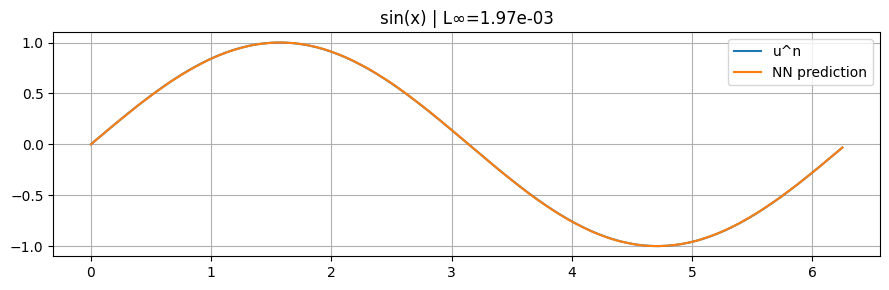

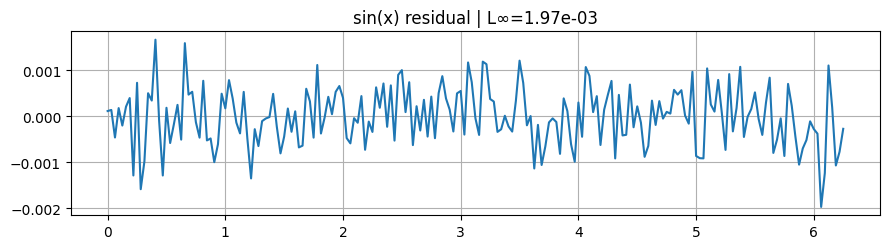

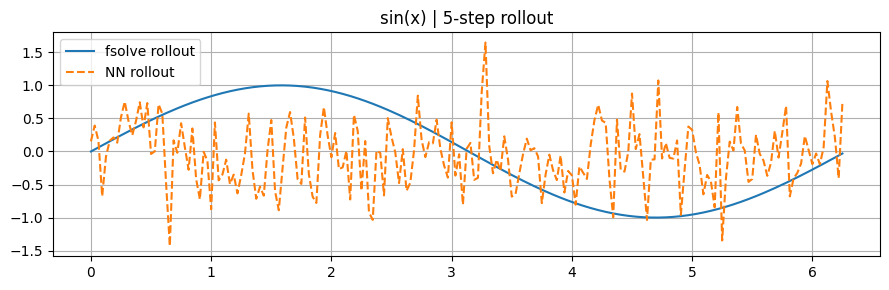


--- 0.5+0.25sin(x) ---
[test] 0.5+0.25sin(x) | L∞=3.545e-01 | Mean=1.054e-01
NN inference : 8.751 ms
fsolve solve : 12.468 ms
5-step rollout: 0.025 sec
Memory usage : 772.07 MB


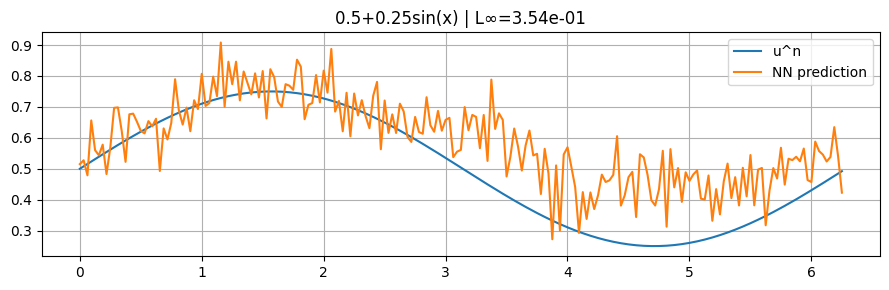

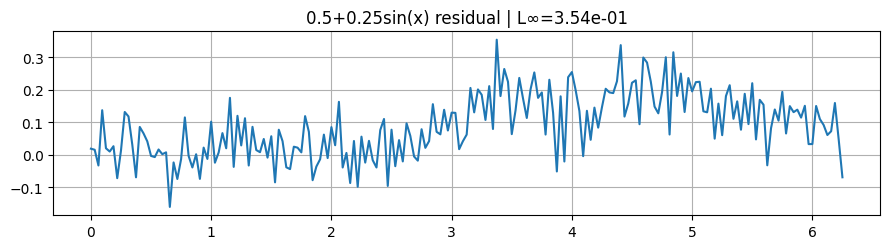

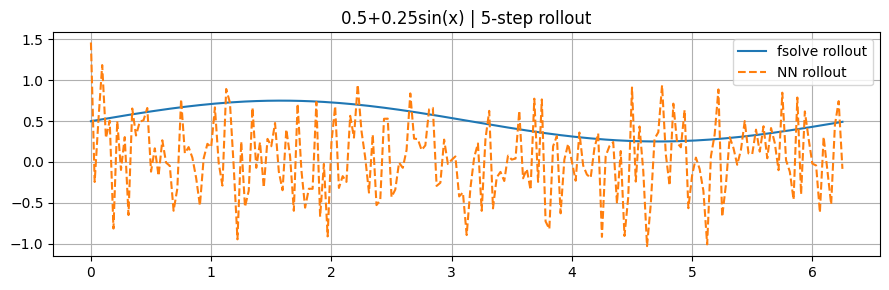


--- sin(sqrt(2)x) ---
[test] sin(sqrt(2)x) | L∞=2.079e-01 | Mean=5.724e-02
NN inference : 6.710 ms
fsolve solve : 13.351 ms
5-step rollout: 0.021 sec
Memory usage : 776.33 MB


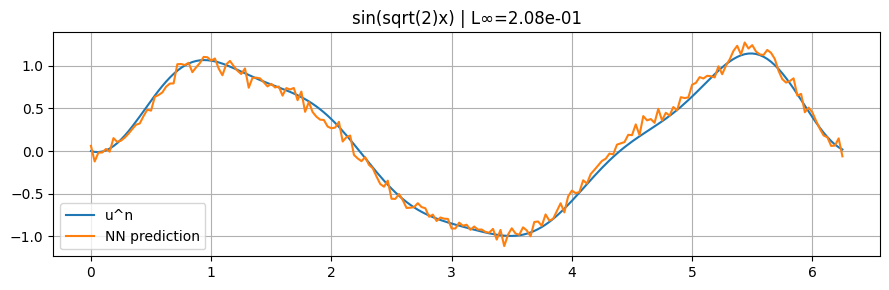

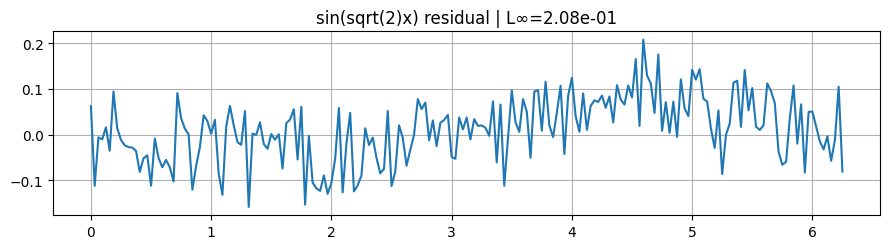

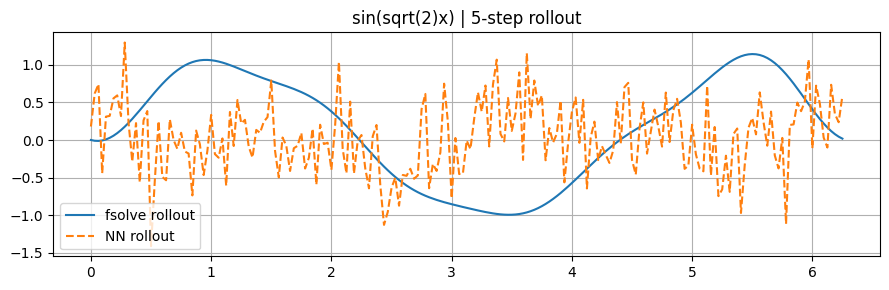


--- cos(sqrt(3)x) ---
[test] cos(sqrt(3)x) | L∞=3.804e-01 | Mean=1.060e-01
NN inference : 5.869 ms
fsolve solve : 13.847 ms
5-step rollout: 0.024 sec
Memory usage : 780.36 MB


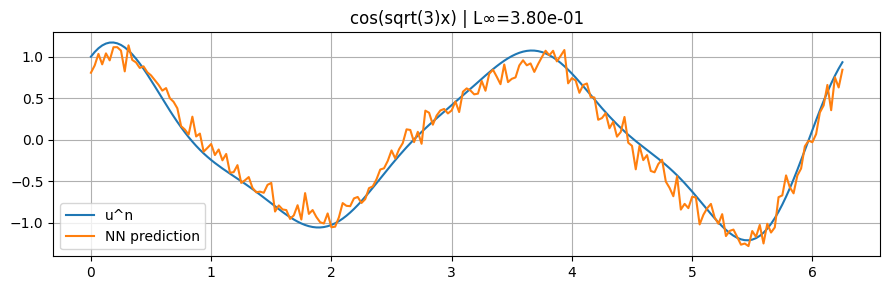

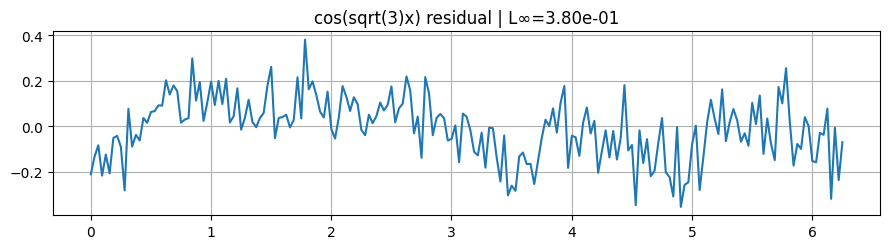

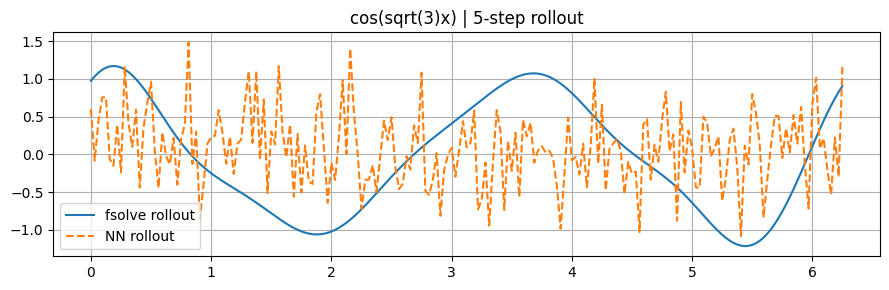


--- exp(-(x-pi)^2)*sin(sqrt(2)x) ---
[test] exp(-(x-pi)^2)*sin(sqrt(2)x) | L∞=5.729e-01 | Mean=1.613e-01
NN inference : 7.510 ms
fsolve solve : 11.978 ms
5-step rollout: 0.024 sec
Memory usage : 783.09 MB


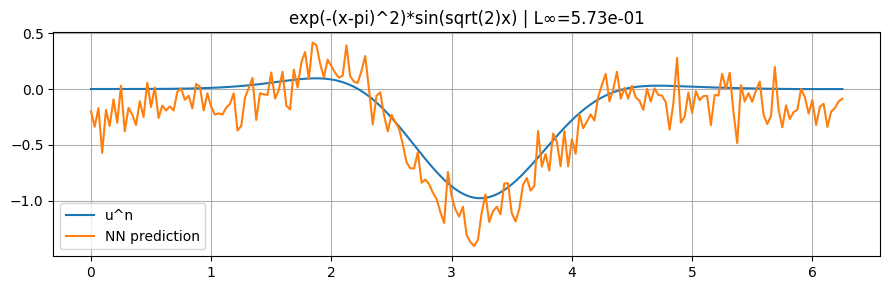

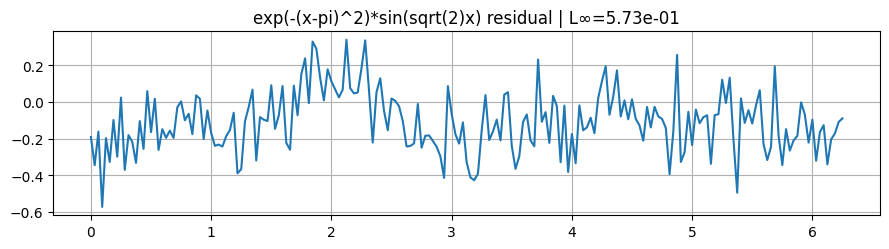

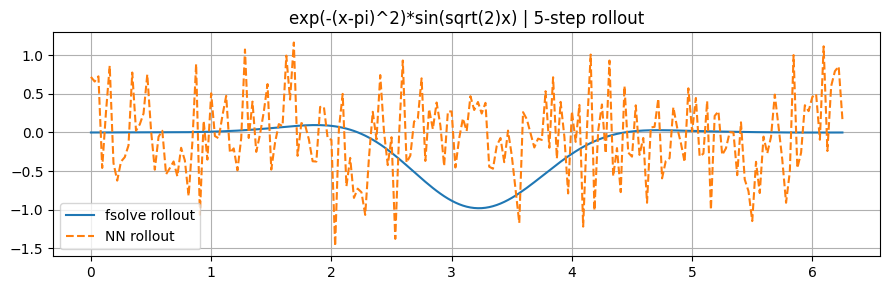


--- ((x-pi)^2)/(pi^2) ---
[test] ((x-pi)^2)/(pi^2) | L∞=3.046e-01 | Mean=9.613e-02
NN inference : 7.292 ms
fsolve solve : 12.685 ms
5-step rollout: 0.022 sec
Memory usage : 787.77 MB


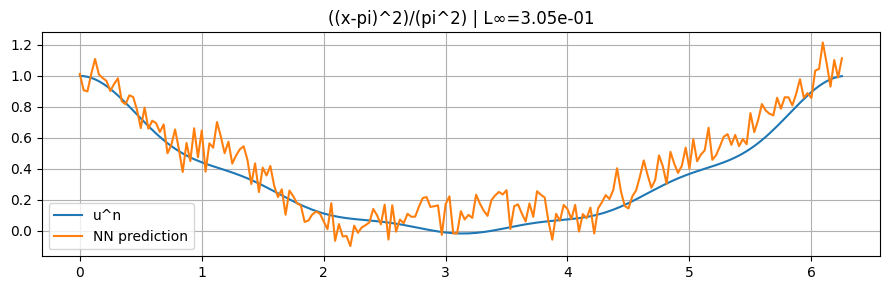

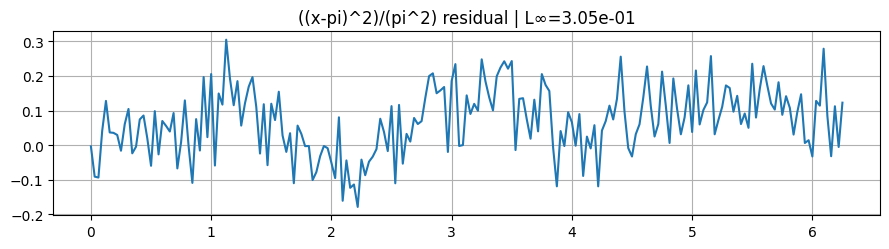

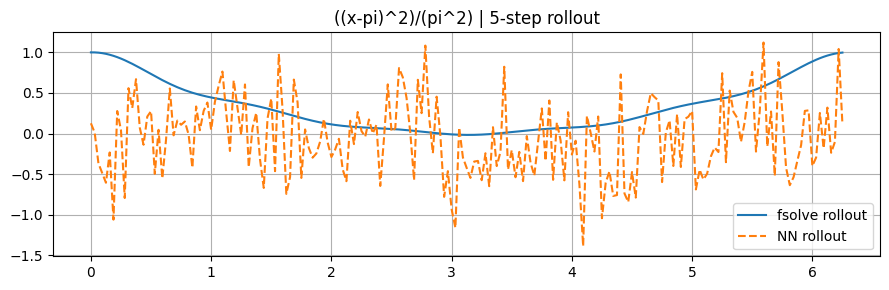


--- (pi^2-(x-pi)^2)/(pi^2) ---
[test] (pi^2-(x-pi)^2)/(pi^2) | L∞=4.647e-01 | Mean=1.352e-01
NN inference : 6.139 ms
fsolve solve : 12.021 ms
5-step rollout: 0.021 sec
Memory usage : 789.78 MB


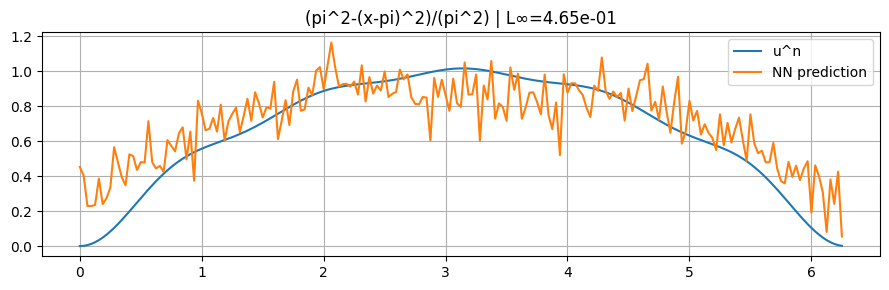

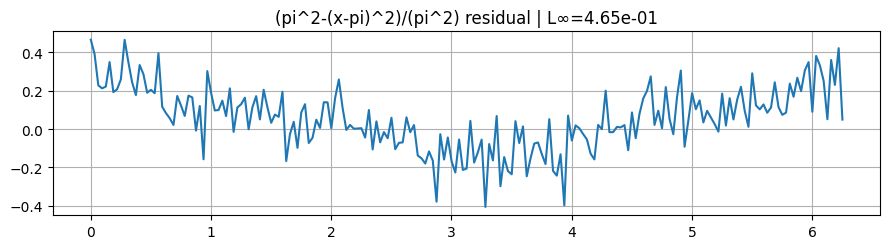

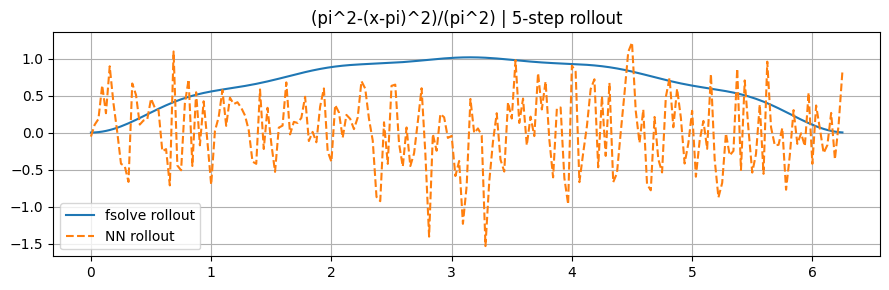


Saved summary CSV:
CaseC_Hybrid_0.005_results\testing_summary_0.005.csv

Plots saved in:
CaseC_Hybrid_0.005_results\plots_0.005


In [10]:
import os
import csv
import time
import psutil

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from scipy.optimize import fsolve

# PATHS
OUT_DIR = "CaseC_Hybrid_0.005_results"

PLOTS_DIR = os.path.join(OUT_DIR, "plots_0.005")
os.makedirs(PLOTS_DIR, exist_ok=True)

WEIGHTS_FILE = os.path.join(
    OUT_DIR,
    "caseC_hybrid_0.005.weights.h5"
)

META_FILE = os.path.join(
    OUT_DIR,
    "caseC_hybrid_meta_0.005.npz"
)

CSV_FILE = os.path.join(
    OUT_DIR,
    "testing_summary_0.005.csv"
)

# MEMORY
process = psutil.Process(os.getpid())

def memory_mb():

    return process.memory_info().rss / 1024**2


# LOAD META
meta = np.load(META_FILE, allow_pickle=True)

NX_FINE   = int(meta["NX_FINE"])
NX_COARSE = int(meta["NX_COARSE"])

DT = float(meta["DT"])
L  = float(meta["L"])

HIDDEN_UNITS = int(meta["HIDDEN_UNITS"])
DEPTH        = int(meta["DEPTH"])
SIREN_W0     = float(meta["SIREN_W0"])

feat_mean = meta["feat_mean"]
feat_std  = meta["feat_std"]

# GRIDS
x_coarse = np.linspace(
    0,
    L,
    NX_COARSE,
    endpoint=False
)

x_fine = np.linspace(
    0,
    L,
    NX_FINE,
    endpoint=False
)

# Differentiaiton matrix
def generate_D_matrix(Nx, L):

    k = 2*np.pi*1j*np.fft.fftfreq(
        Nx,
        d=L/Nx
    )

    I = np.eye(Nx)

    D_fft = np.fft.ifft(
        k[:, None] * np.fft.fft(I, axis=0),
        axis=0
    )

    return D_fft.real

D_np = generate_D_matrix(NX_FINE, L)

# Residual
def residual_np(y, u):

    return y - u + 0.25*DT*(D_np @ (y**2))

# Fourier Interpolation
def fourier_interpolate(u_coarse, Nc, Nf):

    Uc = np.fft.fft(u_coarse)

    Uc_shift = np.fft.fftshift(Uc)

    pad_total = max(Nf-Nc, 0)

    pad_left  = pad_total // 2
    pad_right = pad_total - pad_left

    Uc_padded_shift = np.pad(
        Uc_shift,
        (pad_left, pad_right),
        mode="constant"
    )

    Uc_padded = np.fft.ifftshift(
        Uc_padded_shift
    )

    u_fine = np.fft.ifft(Uc_padded) * (Nf/Nc)

    return u_fine.real

# Fsolve
def compute_y1_fsolve(un):

    un = np.asarray(un, dtype=np.float64)

    N = un.size

    def F(y):

        return y - un + 0.25*DT*(D_np @ (y**2))

    def J(y):

        return np.eye(N) + 0.5*DT*(D_np @ np.diag(y))

    y0 = un.copy()

    y_sol = fsolve(
        F,
        y0,
        fprime=J,
        xtol=1e-12
    )

    return y_sol.astype(np.float64)

# Siren layer
class SineDense(tf.keras.layers.Layer):

    def __init__(
        self,
        units,
        w0=30.0,
        is_first=False,
        **kwargs
    ):

        super().__init__(
            dtype=tf.float64,
            **kwargs
        )

        self.units = int(units)

        self.w0 = float(w0)

        self.is_first = bool(is_first)

    def build(self, input_shape):

        in_dim = int(input_shape[-1])

        bound = (
            (1.0/in_dim)
            if self.is_first
            else
            (np.sqrt(6.0/in_dim)/self.w0)
        )

        self.W = self.add_weight(
            shape=(in_dim, self.units),
            initializer=tf.keras.initializers.RandomUniform(
                -bound,
                bound
            ),
            trainable=True,
            dtype=tf.float64
        )

        self.b = self.add_weight(
            shape=(self.units,),
            initializer="zeros",
            trainable=True,
            dtype=tf.float64
        )

    def call(self, x):

        return tf.sin(
            self.w0 * (
                tf.matmul(x, self.W) + self.b
            )
        )

# Build model
def build_model():

    input_dim = len(feat_mean)

    inputs = tf.keras.Input(
        shape=(input_dim,),
        dtype=tf.float64
    )

    h = inputs

    h = SineDense(
        HIDDEN_UNITS,
        w0=SIREN_W0,
        is_first=True
    )(h)

    for _ in range(DEPTH-1):

        h = SineDense(
            HIDDEN_UNITS,
            w0=SIREN_W0
        )(h)

    outputs = tf.keras.layers.Dense(
        NX_FINE,
        dtype=tf.float64
    )(h)

    return tf.keras.Model(inputs, outputs)

model = build_model()

_ = model(
    tf.zeros((1, len(feat_mean)), dtype=tf.float64)
)

model.load_weights(WEIGHTS_FILE)

print("\nLoaded saved model.")

# SAFE FILENAME
def safe_filename(name):

    return (
        name.replace("(", "")
            .replace(")", "")
            .replace("*", "")
            .replace("^", "")
            .replace("+", "")
            .replace("-", "")
            .replace("/", "_")
            .replace("\\", "_")
            .replace("=", "_")
            .replace(" ", "_")
    )

# Features
def build_feat_single(u_f):

    mag = np.abs(
        np.fft.fft(u_f)
    )[:NX_FINE//2+1]

    mag = 0.2 * mag

    feats = np.concatenate([u_f, mag])

    return (
        (feats - feat_mean) / feat_std
    )[None, :]

# Rollout
def rollout_nn(u0, steps=5):

    u = u0.copy()

    traj = [u.copy()]

    for _ in range(steps):

        feat = build_feat_single(u)

        y = model(
            tf.constant(feat, dtype=tf.float64),
            training=False
        ).numpy()[0]

        u = y.copy()

        traj.append(u.copy())

    return traj

# NORMALIZED OOD TEST FUNCTIONS
tests = [
    (
        "sin(x)",
        lambda x: np.sin(x)
    ),
    
    (
        "0.5+0.25sin(x)",
        lambda x: 0.5 + 0.25*np.sin(x)
    ), 
    # Irrational-frequency sin/cos
    (
        "sin(sqrt(2)x)",
        lambda x: np.sin(np.sqrt(2)*x)
    ),

    (
        "cos(sqrt(3)x)",
        lambda x: np.cos(np.sqrt(3)*x)
    ),   
    # Gaussian + irrational frequency
    (
        "exp(-(x-pi)^2)*sin(sqrt(2)x)",
        lambda x: np.exp(-(x - np.pi)**2)
                  * np.sin(np.sqrt(2)*x)
    ),      
    # Normalised polynomial family
    (
        "((x-pi)^2)/(pi^2)",
        lambda x: ((x - np.pi)**2) / (np.pi**2)
    ),

    (
        "(pi^2-(x-pi)^2)/(pi^2)",
        lambda x: (np.pi**2 - (x - np.pi)**2) / (np.pi**2)
    )
    
]

summary = []

# TESTING
print("\nTEST & DIAGNOSTICS")
for name, fn in tests:

    print("\n---", name, "---")

    safe_name = safe_filename(name)
    
    # initial condition
    uf = fourier_interpolate(
        fn(x_coarse),
        NX_COARSE,
        NX_FINE
    )

    # NN prediction timing
    feat = build_feat_single(uf)

    t0 = time.perf_counter()

    y_pred = model(
        tf.constant(feat, dtype=tf.float64),
        training=False
    ).numpy()[0]

    t1 = time.perf_counter()

    nn_ms = 1000 * (t1 - t0)

    # fsolve timing
    fs0 = time.perf_counter()

    y_fs = compute_y1_fsolve(uf)

    fs1 = time.perf_counter()

    fsolve_ms = 1000 * (fs1 - fs0)

    # residual
    r = residual_np(y_pred, uf)

    Linf = float(np.max(np.abs(r)))

    Mean = float(np.mean(np.abs(r)))

    # rollout timing
    steps = 5

    r0 = time.perf_counter()

    traj_nn = rollout_nn(uf, steps)

    r1 = time.perf_counter()

    rollout_sec = r1 - r0

    # fsolve rollout

    traj_fs = [uf.copy()]

    tmp = uf.copy()

    for _ in range(steps):

        tmp = compute_y1_fsolve(tmp)

        traj_fs.append(tmp.copy())

    mem_now = memory_mb()

    print(
        f"[test] {name:12s} | "
        f"L∞={Linf:.3e} | "
        f"Mean={Mean:.3e}"
    )

    print(f"NN inference : {nn_ms:.3f} ms")

    print(f"fsolve solve : {fsolve_ms:.3f} ms")

    print(f"5-step rollout: {rollout_sec:.3f} sec")

    print(f"Memory usage : {mem_now:.2f} MB")

    xs = x_fine

    # Solution plot
    plt.figure(figsize=(9,3))

    plt.plot(xs, uf, label="u^n")

    plt.plot(xs, y_pred, label="NN prediction")

    plt.legend()

    plt.title(f"{name} | L∞={Linf:.2e}")

    plt.grid(True)

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            PLOTS_DIR,
            f"{safe_name}_nn.png"
        ),
        dpi=150
    )

    plt.show()

    # Residual plot
    plt.figure(figsize=(9,2.6))

    plt.plot(xs, r)

    plt.title(f"{name} residual | L∞={Linf:.2e}")

    plt.grid(True)

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            PLOTS_DIR,
            f"{safe_name}_res.png"
        ),
        dpi=150
    )

    plt.show()

    # Rollout plot
    plt.figure(figsize=(9,3))

    plt.plot(
        xs,
        traj_fs[-1],
        label="fsolve rollout"
    )

    plt.plot(
        xs,
        traj_nn[-1],
        "--",
        label="NN rollout"
    )

    plt.legend()

    plt.title(f"{name} | {steps}-step rollout")

    plt.grid(True)

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            PLOTS_DIR,
            f"{safe_name}_rollout.png"
        ),
        dpi=150
    )

    plt.show()

    summary.append([

        name,

        Linf,

        Mean,

        nn_ms,

        fsolve_ms,

        rollout_sec,

        mem_now
    ])

# SAVE CSV
with open(CSV_FILE, "w", newline="") as f:

    writer = csv.writer(f)

    writer.writerow([

        "Function",

        "Linf",

        "MeanResidual",

        "NN_Inference_ms",

        "fsolve_ms",

        "Rollout_sec",

        "Memory_MB"
    ])

    writer.writerows(summary)

print("\nSaved summary CSV:")

print(CSV_FILE)

print("\nPlots saved in:")

print(PLOTS_DIR)